In [1]:
import os
import json
import random
import hashlib
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
from PIL import Image, ImageOps

import matplotlib.pyplot as plt

import torch

try:
    import cv2
    CV2_AVAILABLE = True
except Exception as e:
    CV2_AVAILABLE = False
    print("cv2 not available:", e)

print("Python OK")
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA capability:", torch.cuda.get_device_capability(0))

def seed_everything(seed: int = 1337):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(1337)

Python OK
Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA capability: (7, 5)


In [2]:
@dataclass
class CFG:
    seed: int = 1337
    img_size: int = 224

    base_dir: str = "/kaggle/input/datasets/saifullahsharafatfb/tea-leaf701515/tea_leaf_processed_dataset/tea_leaf_processed_dataset"

    train_dir: str = "/kaggle/input/datasets/saifullahsharafatfb/tea-leaf701515/tea_leaf_processed_dataset/tea_leaf_processed_dataset/train"
    val_dir: str = "/kaggle/input/datasets/saifullahsharafatfb/tea-leaf701515/tea_leaf_processed_dataset/tea_leaf_processed_dataset/val"
    test_dir: str = "/kaggle/input/datasets/saifullahsharafatfb/tea-leaf701515/tea_leaf_processed_dataset/tea_leaf_processed_dataset/test"

    work_dir: str = "/kaggle/working/fitcp_artifacts"

    classes: Tuple[str, ...] = (
        "Brown Blight",
        "Gray Blight",
        "Green mirid bug",
        "Healthy leaf",
        "Helopeltis",
        "Red spider",
        "Tea algal leaf spot",
    )

    image_exts: Tuple[str, ...] = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

cfg = CFG()
seed_everything(cfg.seed)

Path(cfg.work_dir).mkdir(parents=True, exist_ok=True)

print(json.dumps(asdict(cfg), indent=2))

# Path fallback search if user path changes slightly
if not Path(cfg.base_dir).exists():
    print("Configured base_dir not found. Searching /kaggle/input ...")
    candidates = list(Path("/kaggle/input").rglob("tea_leaf_processed_dataset"))
    for c in candidates[:20]:
        print("Candidate:", c)
    raise FileNotFoundError("base_dir not found. Check the printed candidates.")

for split_name, split_dir in [("train", cfg.train_dir), ("val", cfg.val_dir), ("test", cfg.test_dir)]:
    split_path = Path(split_dir)
    print(f"\nChecking {split_name}: {split_path}")
    if not split_path.exists():
        raise FileNotFoundError(f"{split_name} directory does not exist: {split_path}")

    found_classes = sorted([p.name for p in split_path.iterdir() if p.is_dir()])
    print("Found classes:", found_classes)

    missing = [c for c in cfg.classes if c not in found_classes]
    extra = [c for c in found_classes if c not in cfg.classes]

    if missing:
        raise ValueError(f"Missing classes in {split_name}: {missing}")
    if extra:
        print(f"Warning: extra folders in {split_name}: {extra}")

print("\nAll paths and class folders look valid.")

{
  "seed": 1337,
  "img_size": 224,
  "base_dir": "/kaggle/input/datasets/saifullahsharafatfb/tea-leaf701515/tea_leaf_processed_dataset/tea_leaf_processed_dataset",
  "train_dir": "/kaggle/input/datasets/saifullahsharafatfb/tea-leaf701515/tea_leaf_processed_dataset/tea_leaf_processed_dataset/train",
  "val_dir": "/kaggle/input/datasets/saifullahsharafatfb/tea-leaf701515/tea_leaf_processed_dataset/tea_leaf_processed_dataset/val",
  "test_dir": "/kaggle/input/datasets/saifullahsharafatfb/tea-leaf701515/tea_leaf_processed_dataset/tea_leaf_processed_dataset/test",
  "work_dir": "/kaggle/working/fitcp_artifacts",
  "classes": [
    "Brown Blight",
    "Gray Blight",
    "Green mirid bug",
    "Healthy leaf",
    "Helopeltis",
    "Red spider",
    "Tea algal leaf spot"
  ],
  "image_exts": [
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
  ]
}

Checking train: /kaggle/input/datasets/saifullahsharafatfb/tea-leaf701515/tea_leaf_processed_dataset/tea_leaf_processed_dataset/train

In [3]:
def list_images(split_dir: str, split_name: str, classes: Tuple[str, ...], exts: Tuple[str, ...]) -> pd.DataFrame:
    rows = []

    for class_idx, class_name in enumerate(classes):
        class_dir = Path(split_dir) / class_name
        files = []

        for ext in exts:
            files.extend(class_dir.glob(f"*{ext}"))
            files.extend(class_dir.glob(f"*{ext.upper()}"))

        files = sorted(set(files))

        for fp in files:
            rows.append({
                "split": split_name,
                "class_name": class_name,
                "class_idx": class_idx,
                "filepath": str(fp),
                "filename": fp.name,
                "suffix": fp.suffix.lower(),
            })

    return pd.DataFrame(rows)

df_train = list_images(cfg.train_dir, "train", cfg.classes, cfg.image_exts)
df_val   = list_images(cfg.val_dir, "val", cfg.classes, cfg.image_exts)
df_test  = list_images(cfg.test_dir, "test", cfg.classes, cfg.image_exts)

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)

print("Total images:", len(df_all))
print(df_all.head())

counts = (
    df_all
    .groupby(["split", "class_name"])
    .size()
    .reset_index(name="count")
    .pivot(index="class_name", columns="split", values="count")
    .fillna(0)
    .astype(int)
)

# Preserve class order
counts = counts.loc[list(cfg.classes)]
counts["total"] = counts.sum(axis=1)

print("\nClass counts:")
display(counts)

df_all.to_csv(Path(cfg.work_dir) / "image_index.csv", index=False)
counts.to_csv(Path(cfg.work_dir) / "class_counts.csv")

class_to_idx = {c: i for i, c in enumerate(cfg.classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

with open(Path(cfg.work_dir) / "class_to_idx.json", "w") as f:
    json.dump(class_to_idx, f, indent=2)

print("\nSaved:")
print(Path(cfg.work_dir) / "image_index.csv")
print(Path(cfg.work_dir) / "class_counts.csv")
print(Path(cfg.work_dir) / "class_to_idx.json")

Total images: 7794
   split    class_name  class_idx  \
0  train  Brown Blight          0   
1  train  Brown Blight          0   
2  train  Brown Blight          0   
3  train  Brown Blight          0   
4  train  Brown Blight          0   

                                            filepath  \
0  /kaggle/input/datasets/saifullahsharafatfb/tea...   
1  /kaggle/input/datasets/saifullahsharafatfb/tea...   
2  /kaggle/input/datasets/saifullahsharafatfb/tea...   
3  /kaggle/input/datasets/saifullahsharafatfb/tea...   
4  /kaggle/input/datasets/saifullahsharafatfb/tea...   

                                      filename suffix  
0               UNADJUSTEDNONRAW_thumb_103.jpg   .jpg  
1  UNADJUSTEDNONRAW_thumb_103_aug_contrast.jpg   .jpg  
2               UNADJUSTEDNONRAW_thumb_104.jpg   .jpg  
3  UNADJUSTEDNONRAW_thumb_104_aug_rotation.jpg   .jpg  
4      UNADJUSTEDNONRAW_thumb_104_aug_zoom.jpg   .jpg  

Class counts:


split,test,train,val,total
class_name,,,,
Brown Blight,93,858,93,1044
Gray Blight,167,897,167,1231
Green mirid bug,193,897,192,1282
Healthy leaf,151,893,151,1195
Helopeltis,91,863,91,1045
Red spider,77,835,78,990
Tea algal leaf spot,80,848,79,1007



Saved:
/kaggle/working/fitcp_artifacts/image_index.csv
/kaggle/working/fitcp_artifacts/class_counts.csv
/kaggle/working/fitcp_artifacts/class_to_idx.json


In [4]:
def file_md5(path: str, chunk_size: int = 8192) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def validate_images(df: pd.DataFrame, max_check: int = None) -> pd.DataFrame:
    records = []
    check_df = df if max_check is None else df.sample(min(max_check, len(df)), random_state=cfg.seed)

    for i, row in check_df.iterrows():
        fp = row["filepath"]
        ok = True
        err = ""
        w, h = None, None

        try:
            with Image.open(fp) as img:
                img = ImageOps.exif_transpose(img)
                w, h = img.size
                img.verify()
        except Exception as e:
            ok = False
            err = str(e)

        records.append({
            "filepath": fp,
            "ok": ok,
            "width": w,
            "height": h,
            "error": err,
        })

    return pd.DataFrame(records)

print("Checking image readability...")
read_check = validate_images(df_all, max_check=None)

bad = read_check[~read_check["ok"]]
print("Bad images:", len(bad))
if len(bad) > 0:
    display(bad.head(20))

read_check.to_csv(Path(cfg.work_dir) / "image_readability_check.csv", index=False)

print("Computing MD5 hashes for leakage check...")
df_all["md5"] = df_all["filepath"].apply(file_md5)

dup = (
    df_all
    .groupby("md5")
    .agg(
        n=("filepath", "count"),
        splits=("split", lambda x: sorted(set(x))),
        classes=("class_name", lambda x: sorted(set(x))),
        paths=("filepath", lambda x: list(x)[:5]),
    )
    .reset_index()
)

dup = dup[dup["n"] > 1].copy()
cross_split_dup = dup[dup["splits"].apply(lambda x: len(x) > 1)]

print("Total duplicate hashes:", len(dup))
print("Cross-split duplicate hashes:", len(cross_split_dup))

if len(cross_split_dup) > 0:
    print("WARNING: Cross-split duplicates found.")
    display(cross_split_dup.head(10))

df_all.to_csv(Path(cfg.work_dir) / "image_index_with_md5.csv", index=False)
cross_split_dup.to_csv(Path(cfg.work_dir) / "cross_split_duplicates.csv", index=False)

print("Saved duplicate check files in:", cfg.work_dir)

Checking image readability...
Bad images: 0
Computing MD5 hashes for leakage check...
Total duplicate hashes: 3
Cross-split duplicate hashes: 1


,md5,n,splits,classes,paths
5878,c062f2f3aa9a9b12bfe67a75cf7f495a,2,"[test, train]",[Gray Blight],[/kaggle/input/datasets/saifullahsharafatfb/te...


Saved duplicate check files in: /kaggle/working/fitcp_artifacts


In [5]:
import os
import shutil
import hashlib
import re
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from IPython.display import display

# 1. Setup Paths
orig_base_dir = "/kaggle/input/datasets/saifullahsharafatfb/tea-leaf701515/tea_leaf_processed_dataset/tea_leaf_processed_dataset"
clean_base_dir = "/kaggle/working/tea_leaf_clean"

# 2. Copy dataset to writable working directory (if not already done)
if not os.path.exists(clean_base_dir):
    print(f"Copying dataset to writable directory: {clean_base_dir} ...")
    shutil.copytree(orig_base_dir, clean_base_dir)
    print("Copy complete!")
else:
    print(f"Directory {clean_base_dir} already exists. Proceeding with existing folder.")

# 3. Helper Functions
def compute_md5(file_path):
    hash_md5 = hashlib.md5()
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

AUG_PATTERN = re.compile(
    r"(_aug(_|-)?(rotation|contrast|zoom|flip|brightness|blur|noise|color|crop|.*))$",
    re.IGNORECASE
)

def canonical_stem(filename: str) -> str:
    stem = Path(filename).stem
    return AUG_PATTERN.sub("", stem)

# 4. Index the copied dataset
print("Indexing files in writable directory...")
records = []
for split in ["train", "val", "test"]:
    split_dir = Path(clean_base_dir) / split
    if not split_dir.exists(): continue
    
    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir(): continue
        class_name = class_dir.name
        
        for img_path in class_dir.glob("*.*"):
            if img_path.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
                records.append({
                    "split": split,
                    "class_name": class_name,
                    "filename": img_path.name,
                    "filepath": str(img_path)
                })

df_clean_dir = pd.DataFrame(records)

# 5. Compute Hashes and Canonical IDs
print("Computing MD5 hashes and Canonical IDs...")
tqdm.pandas(desc="Hashing")
df_clean_dir["md5"] = df_clean_dir["filepath"].progress_apply(compute_md5)
df_clean_dir["canonical_id"] = df_clean_dir["filename"].apply(canonical_stem)

# 6. Find Leaks (Compare Train vs Val/Test)
val_test_df = df_clean_dir[df_clean_dir["split"].isin(["val", "test"])]
train_df = df_clean_dir[df_clean_dir["split"] == "train"]

# Exact MD5 leaks
valtest_md5s = set(val_test_df["md5"])
exact_leaks = train_df[train_df["md5"].isin(valtest_md5s)]

# Canonical family leaks
valtest_keys = set(zip(val_test_df["class_name"], val_test_df["canonical_id"]))
train_keys = list(zip(train_df["class_name"], train_df["canonical_id"]))
canonical_leak_mask = pd.Series([key in valtest_keys for key in train_keys], index=train_df.index)
canonical_leaks = train_df[canonical_leak_mask]

# Combine all leaked files to delete
files_to_delete = set(exact_leaks["filepath"].tolist() + canonical_leaks["filepath"].tolist())

print(f"\nFound {len(exact_leaks)} exact MD5 leaks in train.")
print(f"Found {len(canonical_leaks)} canonical-family leaks in train.")
print(f"Total unique files to permanently delete: {len(files_to_delete)}")

# 7. Forcefully Delete Files
deleted_count = 0
for file_path in files_to_delete:
    if os.path.exists(file_path):
        os.remove(file_path)
        deleted_count += 1

print(f"Successfully and permanently deleted {deleted_count} files from disk.")

print(f"Update my training paths to: {clean_base_dir}")

Copying dataset to writable directory: /kaggle/working/tea_leaf_clean ...
Copy complete!
Indexing files in writable directory...
Computing MD5 hashes and Canonical IDs...


Hashing: 100%|██████████| 7794/7794 [00:05<00:00, 1403.81it/s]


Found 1 exact MD5 leaks in train.
Found 0 canonical-family leaks in train.
Total unique files to permanently delete: 1
Successfully and permanently deleted 1 files from disk.
Update my training paths to: /kaggle/working/tea_leaf_clean


In [6]:
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from IPython.display import display

# 1. Update Config to use the NEW clean directory
clean_base_dir = "/kaggle/working/tea_leaf_clean"

# Update your cfg object to point to the new working directory paths
cfg.base_dir = clean_base_dir
cfg.train_dir = f"{clean_base_dir}/train"
cfg.val_dir = f"{clean_base_dir}/val"
cfg.test_dir = f"{clean_base_dir}/test"

# 2. Define Image Listing Function
def list_images(split_dir: str, split_name: str, classes: list, exts: list) -> pd.DataFrame:
    rows = []
    for class_idx, class_name in enumerate(classes):
        class_dir = Path(split_dir) / class_name
        files = []
        for ext in exts:
            files.extend(class_dir.glob(f"*{ext}"))
            files.extend(class_dir.glob(f"*{ext.upper()}"))
        files = sorted(set(files))
        for fp in files:
            rows.append({
                "split": split_name,
                "class_name": class_name,
                "class_idx": class_idx,
                "filepath": str(fp),
                "filename": fp.name,
                "suffix": fp.suffix.lower(),
            })
    return pd.DataFrame(rows)

# 3. Re-index the Dataset from the Clean Directory
print(f"Re-indexing from clean directory: {cfg.base_dir}")
df_train = list_images(cfg.train_dir, "train", cfg.classes, cfg.image_exts)
df_val   = list_images(cfg.val_dir, "val", cfg.classes, cfg.image_exts)
df_test  = list_images(cfg.test_dir, "test", cfg.classes, cfg.image_exts)

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
print("\nTotal images after cleanup:", len(df_all))

# 4. Generate and Display the Updated Class Counts
counts = (
    df_all
    .groupby(["split", "class_name"])
    .size()
    .reset_index(name="count")
    .pivot(index="class_name", columns="split", values="count")
    .fillna(0)
    .astype(int)
)

# Preserve class order
counts = counts.loc[list(cfg.classes)]
counts["total"] = counts.sum(axis=1)

print("\nUpdated Class Counts:")
display(counts)

# 5. Final Verification Sweep (Sanity Check)
print("\nRunning final duplicate check to confirm zero leaks...")
tqdm.pandas(desc="Hashing Final Index")
df_all["md5"] = df_all["filepath"].progress_apply(compute_md5)

val_test_md5s = set(df_all[df_all["split"].isin(["val", "test"])]["md5"])
train_leaks = df_all[(df_all["split"] == "train") & (df_all["md5"].isin(val_test_md5s))]

if len(train_leaks) == 0:
    print("SUCCESS: 0 cross-split duplicates found. The dataset is now perfect.")
else:
    print(f"WARNING: Found {len(train_leaks)} remaining duplicates!")

# 6. Save Final Clean Artifacts
df_all.to_csv(Path(cfg.work_dir) / "image_index_clean.csv", index=False)
counts.to_csv(Path(cfg.work_dir) / "class_counts_clean.csv")

class_to_idx = {c: i for i, c in enumerate(cfg.classes)}
with open(Path(cfg.work_dir) / "class_to_idx.json", "w") as f:
    json.dump(class_to_idx, f, indent=2)

print("\nSaved Final Artifacts:")
print(Path(cfg.work_dir) / "image_index_clean.csv")
print(Path(cfg.work_dir) / "class_counts_clean.csv")
print(Path(cfg.work_dir) / "class_to_idx.json")

Re-indexing from clean directory: /kaggle/working/tea_leaf_clean

Total images after cleanup: 7793

Updated Class Counts:


split,test,train,val,total
class_name,,,,
Brown Blight,93,858,93,1044
Gray Blight,167,896,167,1230
Green mirid bug,193,897,192,1282
Healthy leaf,151,893,151,1195
Helopeltis,91,863,91,1045
Red spider,77,835,78,990
Tea algal leaf spot,80,848,79,1007



Running final duplicate check to confirm zero leaks...


Hashing Final Index: 100%|██████████| 7793/7793 [00:05<00:00, 1432.55it/s]


SUCCESS: 0 cross-split duplicates found. The dataset is now perfect.

Saved Final Artifacts:
/kaggle/working/fitcp_artifacts/image_index_clean.csv
/kaggle/working/fitcp_artifacts/class_counts_clean.csv
/kaggle/working/fitcp_artifacts/class_to_idx.json


Loaded clean index: /kaggle/working/fitcp_artifacts/image_index_clean.csv
Total images: 7793
Train: 6090
Val: 851
Test: 852


split,test,train,val
class_name,,,
Brown Blight,93,858,93
Gray Blight,167,896,167
Green mirid bug,193,897,192
Healthy leaf,151,893,151
Helopeltis,91,863,91
Red spider,77,835,78
Tea algal leaf spot,80,848,79


Canonical-family cross-split cases after cleanup: 0
Canonical-family check looks clean.
Saved: /kaggle/working/fitcp_artifacts/sample_grid_train.png


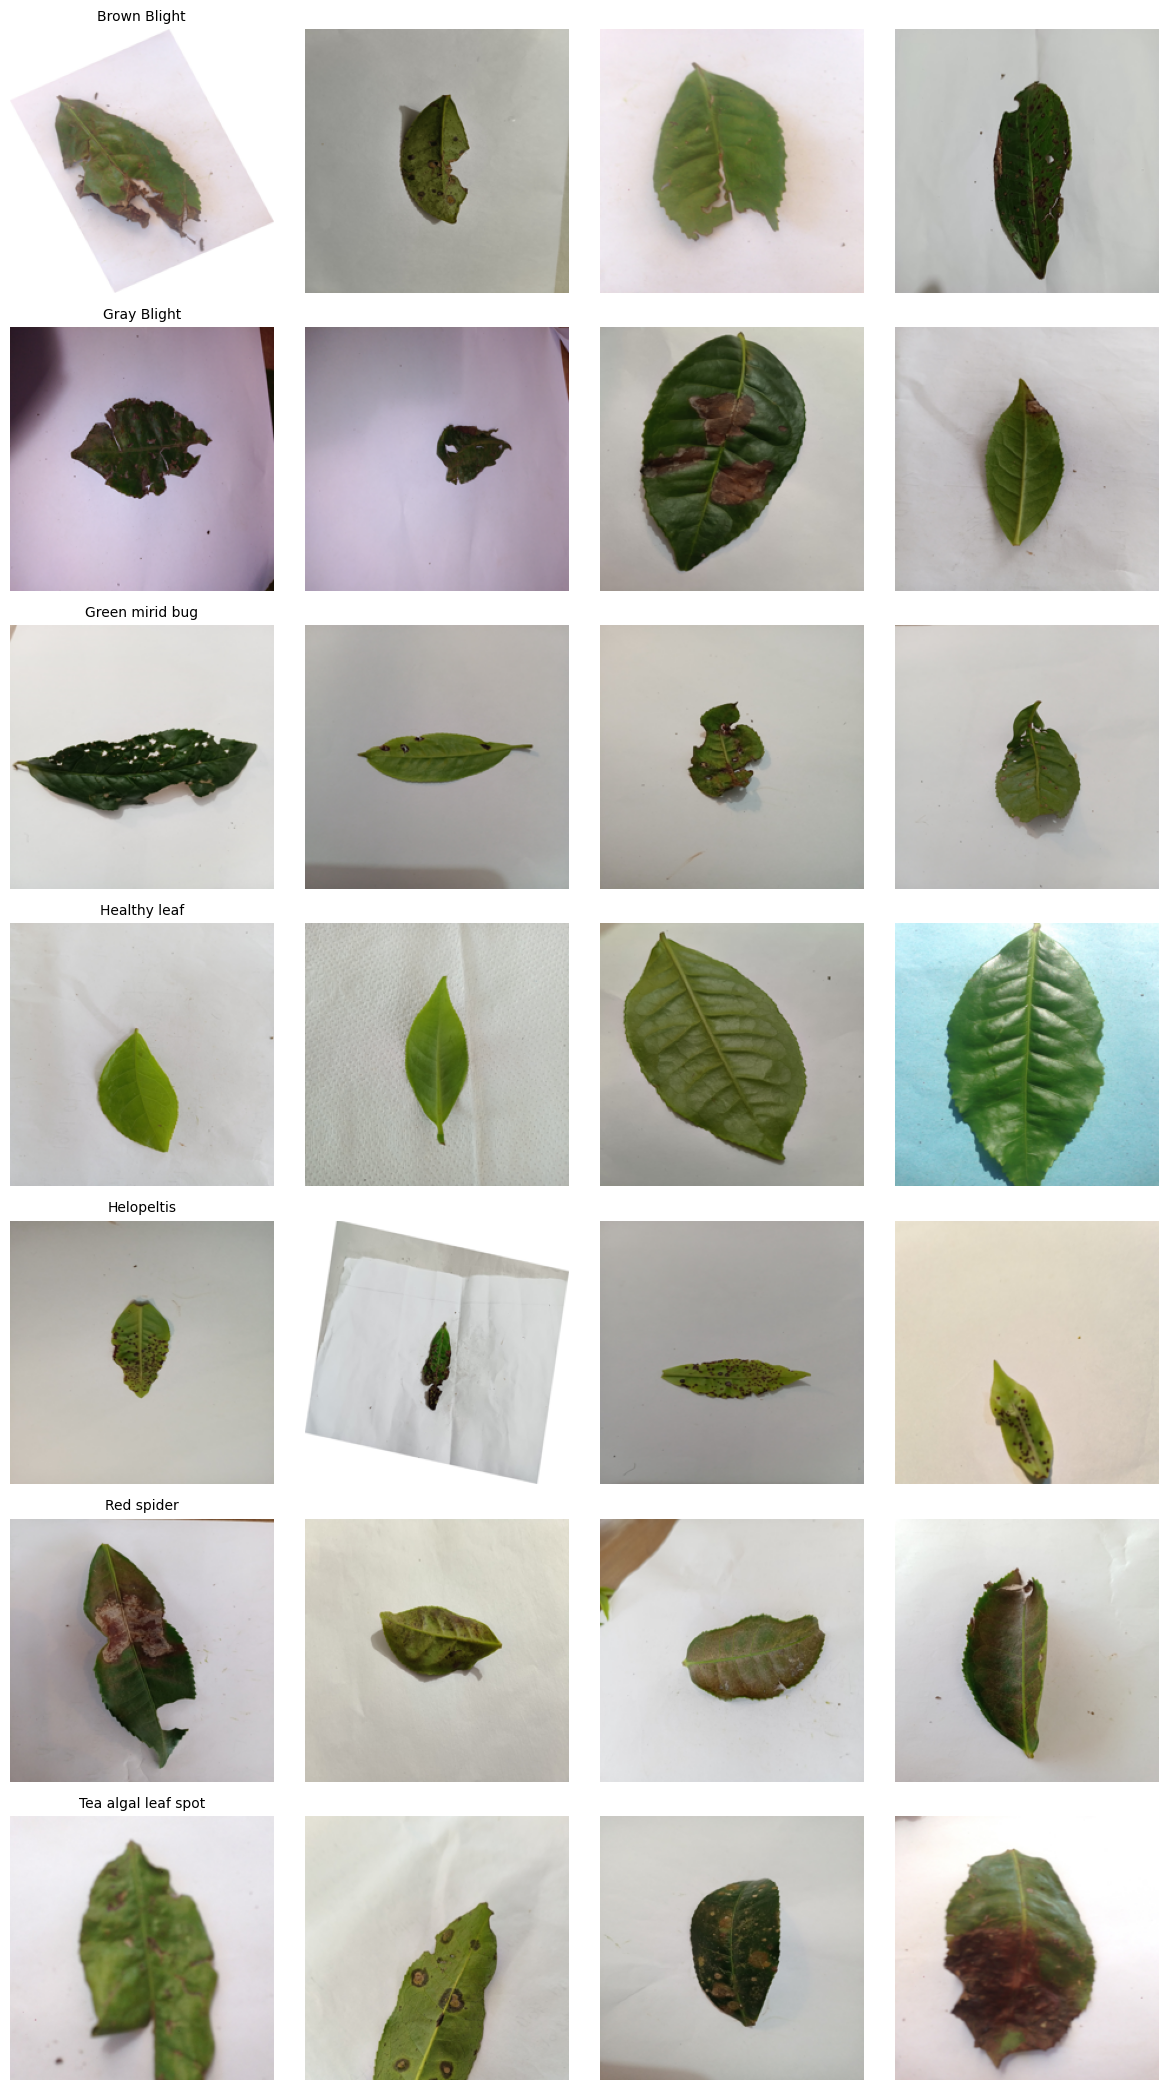

In [7]:
import os
import re
import json
import random
import hashlib
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps
from IPython.display import display
from tqdm import tqdm

# Use the clean writable dataset
clean_base_dir = "/kaggle/working/tea_leaf_clean"

cfg.base_dir = clean_base_dir
cfg.train_dir = f"{clean_base_dir}/train"
cfg.val_dir = f"{clean_base_dir}/val"
cfg.test_dir = f"{clean_base_dir}/test"

clean_index_path = Path(cfg.work_dir) / "image_index_clean.csv"
df_all = pd.read_csv(clean_index_path)

print("Loaded clean index:", clean_index_path)
print("Total images:", len(df_all))
print("Train:", (df_all["split"] == "train").sum())
print("Val:", (df_all["split"] == "val").sum())
print("Test:", (df_all["split"] == "test").sum())

display(
    df_all.groupby(["split", "class_name"])
    .size()
    .reset_index(name="count")
    .pivot(index="class_name", columns="split", values="count")
    .fillna(0)
    .astype(int)
    .loc[list(cfg.classes)]
)

# Optional canonical family sanity check
AUG_PATTERN = re.compile(
    r"(_aug(_|-)?(rotation|contrast|zoom|flip|brightness|blur|noise|color|crop|.*))$",
    re.IGNORECASE
)

def canonical_stem(filename: str) -> str:
    stem = Path(filename).stem
    return AUG_PATTERN.sub("", stem)

df_all["canonical_id"] = df_all["filename"].apply(canonical_stem)

canon_summary = (
    df_all
    .groupby(["class_name", "canonical_id"])
    .agg(
        n=("filepath", "count"),
        splits=("split", lambda x: sorted(set(x))),
        filenames=("filename", lambda x: sorted(list(set(x)))[:8]),
    )
    .reset_index()
)

canon_cross_split = canon_summary[
    canon_summary["splits"].apply(lambda x: len(x) > 1)
]

print("Canonical-family cross-split cases after cleanup:", len(canon_cross_split))
if len(canon_cross_split) > 0:
    display(canon_cross_split.head(20))
else:
    print("Canonical-family check looks clean.")


def load_rgb(path: str, size: int = None) -> Image.Image:
    img = Image.open(path)
    img = ImageOps.exif_transpose(img)
    img = img.convert("RGB")
    if size is not None:
        img = img.resize((size, size), Image.BICUBIC)
    return img

def show_samples_grid(df: pd.DataFrame, split: str = "train", n_per_class: int = 4, save_path: str = None):
    sub = df[df["split"] == split].copy()

    n_rows = len(cfg.classes)
    n_cols = n_per_class

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))

    for r, class_name in enumerate(cfg.classes):
        class_df = sub[sub["class_name"] == class_name]
        sample_df = class_df.sample(min(n_per_class, len(class_df)), random_state=cfg.seed)

        for c in range(n_cols):
            ax = axes[r, c] if n_rows > 1 else axes[c]
            ax.axis("off")

            if c < len(sample_df):
                row = sample_df.iloc[c]
                img = load_rgb(row["filepath"], size=224)
                ax.imshow(img)
                if c == 0:
                    ax.set_title(class_name, fontsize=10)
            else:
                ax.set_title("")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

sample_grid_path = str(Path(cfg.work_dir) / "sample_grid_train.png")
show_samples_grid(df_all, split="train", n_per_class=4, save_path=sample_grid_path)

> Main Script

In [8]:
%%writefile train_swin_three_models.py
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import re
import csv
import json
import time
import math
import shutil
import random
import argparse
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List, ContextManager, Union
from collections import Counter
from contextlib import nullcontext

import numpy as np
from tqdm import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

import torchvision.transforms as T
from torchvision.transforms import InterpolationMode
from torchvision.datasets import ImageFolder

import timm
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)


# -------------------------
# Utilities
# -------------------------
def set_seed(seed: int, deterministic: bool = True) -> None:
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.backends.cuda.matmul.allow_tf32 = False
            torch.backends.cudnn.allow_tf32 = False
        except Exception:
            pass

        try:
            torch.use_deterministic_algorithms(True)
        except Exception as e:
            warnings.warn(
                f"Could not enable deterministic algorithms: {e}\n"
                "Training will continue with partial determinism."
            )
    else:
        torch.backends.cudnn.benchmark = True


def worker_init_fn(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def get_autocast_ctx(use_amp: bool) -> ContextManager:
    enabled = bool(use_amp and torch.cuda.is_available())
    if not enabled:
        return nullcontext()
    if hasattr(torch, "amp") and hasattr(torch.amp, "autocast"):
        return torch.amp.autocast(device_type="cuda", enabled=True)
    return torch.cuda.amp.autocast(enabled=True)


def make_grad_scaler(use_amp: bool):
    enabled = bool(use_amp and torch.cuda.is_available())
    try:
        return torch.cuda.amp.GradScaler(enabled=enabled)
    except Exception:
        if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
            return torch.amp.GradScaler(enabled=enabled)
        raise


def rgb_to_hsv_torch(rgb01: torch.Tensor) -> torch.Tensor:
    r, g, b = rgb01[:, 0:1], rgb01[:, 1:2], rgb01[:, 2:3]
    maxc, _ = rgb01.max(dim=1, keepdim=True)
    minc, _ = rgb01.min(dim=1, keepdim=True)
    v = maxc
    delta = maxc - minc
    
    eps = 1e-10
    
    # Saturation
    s = delta / torch.clamp(maxc, min=eps)
    s = torch.where(maxc > eps, s, torch.zeros_like(s))
    
    # Hue computation with deterministic max-channel selection
    delta_safe = torch.clamp(delta, min=eps)
    
    # Compute hue formulas for each channel (standard HSV conversion)
    h_r = (g - b) / delta_safe          # If R is max
    h_g = (b - r) / delta_safe + 2.0    # If G is max
    h_b = (r - g) / delta_safe + 4.0    # If B is max
    
    idx = rgb01.argmax(dim=1, keepdim=True)   # [B,1,H,W] ∈ {0,1,2}
    mask = (delta > eps)                     # [B,1,H,W]

    h = torch.zeros_like(delta, dtype=rgb01.dtype)  # [B,1,H,W]
    h = torch.where((idx == 0) & mask, h_r, h)
    h = torch.where((idx == 1) & mask, h_g, h)
    h = torch.where((idx == 2) & mask, h_b, h)

    # Normalize to [0, 1) with true modulo (handles wraparound correctly)
    h = torch.remainder(h / 6.0, 1.0)
    hsv = torch.cat([h, s, v], dim=1)
    return torch.clamp(hsv, 0.0, 1.0)


def hsv_to_sincos_sv(hsv01: torch.Tensor) -> torch.Tensor:
    """
    HSV [0,1] -> [sin(2πH), cos(2πH), S, V]
    Removes hue discontinuity at wrap-around.
    """
    h = hsv01[:, 0:1]
    s = hsv01[:, 1:2]
    v = hsv01[:, 2:3]
    ang = 2.0 * math.pi * h
    hsin = torch.sin(ang)
    hcos = torch.cos(ang)
    return torch.cat([hsin, hcos, s, v], dim=1)


def normalize_hsv_rep(x: torch.Tensor) -> torch.Tensor:
    """
    x: [hsin, hcos, s, v]
    Keep sin/cos as-is in [-1,1].
    Normalize S,V to roughly zero-mean and stable scale.
    """
    hsin = x[:, 0:1]
    hcos = x[:, 1:2]
    s = (x[:, 2:3] - 0.5) / 0.25
    v = (x[:, 3:4] - 0.5) / 0.25
    return torch.cat([hsin, hcos, s, v], dim=1)


def count_params_m(model: nn.Module) -> float:
    return sum(p.numel() for p in model.parameters()) / 1e6


def try_get_gflops(model: nn.Module, input_size: int, device: str) -> Optional[float]:
    """GFLOPs via ptflops (optional). Returns None if unavailable."""
    try:
        from ptflops import get_model_complexity_info
    except Exception:
        return None

    if isinstance(model, nn.DataParallel):
        model = model.module

    model = model.to(device)
    was_training = model.training
    model.eval()
    try:
        with torch.no_grad():
            macs, _params = get_model_complexity_info(
                model, (3, input_size, input_size),
                as_strings=False,
                print_per_layer_stat=False,
                verbose=False
            )
        flops = 2.0 * float(macs)  # FLOPs ≈ 2*MACs
        return flops / 1e9
    except Exception as e:
        print(f" GFLOPs computation failed: {e}")
        return None
    finally:
        if was_training:
            model.train()


def _json_safe_scalar(x):
    if x is None:
        return None
    if isinstance(x, (int, float, str, bool)):
        return x
    if isinstance(x, np.integer):
        return int(x)
    if isinstance(x, np.floating):
        val = float(x)
        if np.isnan(val) or np.isinf(val):
            return None
        return val
    if isinstance(x, torch.Tensor):
        if x.ndim == 0:
            return _json_safe_scalar(x.item())
        return x.detach().cpu().numpy().tolist()
    if isinstance(x, np.ndarray):
        if x.ndim == 0:
            return _json_safe_scalar(x.item())
        return x.tolist()
    return str(x)


def strip_module_prefix(state_dict: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    out = {}
    for k, v in state_dict.items():
        if k.startswith("module."):
            out[k[7:]] = v
        else:
            out[k] = v
    return out


def add_module_prefix(state_dict: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    out = {}
    for k, v in state_dict.items():
        out[k if k.startswith("module.") else f"module.{k}"] = v
    return out


def load_state_dict_robust(model: nn.Module, state_dict: Dict[str, torch.Tensor]) -> None:
    """
    Robust load:
    - strict=True with (as-is / strip module / add module)
    - strict=False fallback with warnings
    """
    prefix_fns = [lambda x: x, strip_module_prefix, add_module_prefix]

    for fn in prefix_fns:
        try:
            model.load_state_dict(fn(state_dict), strict=True)
            return
        except Exception:
            pass

    for fn in prefix_fns:
        try:
            result = model.load_state_dict(fn(state_dict), strict=False)
            if getattr(result, "missing_keys", None) or getattr(result, "unexpected_keys", None):
                warnings.warn(
                    "Loaded with strict=False:\n"
                    f"  Missing keys: {result.missing_keys}\n"
                    f"  Unexpected keys: {result.unexpected_keys}"
                )
            return
        except Exception:
            pass

    raise RuntimeError("Could not load state dict with any strategy.")


# -------------------------
# EMA
# -------------------------
class EMA:
    def __init__(self, model: nn.Module, decay: float = 0.9998):
        self.model = model
        self.decay = decay
        self.shadow: Dict[str, torch.Tensor] = {}
        self.backup: Dict[str, torch.Tensor] = {}
        for name, p in model.named_parameters():
            if p.requires_grad:
                self.shadow[name] = p.data.clone()

    def update(self):
        for name, p in self.model.named_parameters():
            if p.requires_grad:
                if name not in self.shadow:
                    self.shadow[name] = p.data.clone()
                else:
                    self.shadow[name] = (1.0 - self.decay) * p.data + self.decay * self.shadow[name]

    def apply_shadow(self):
        self.backup = {}
        for name, p in self.model.named_parameters():
            if p.requires_grad and name in self.shadow:
                self.backup[name] = p.data.clone()
                p.data = self.shadow[name].clone()

    def restore(self):
        if not self.backup:
            warnings.warn("EMA.restore() called but backup is empty. Did you call apply_shadow()?")  # harmless
            return
        for name, p in self.model.named_parameters():
            if p.requires_grad and name in self.backup:
                p.data = self.backup[name].clone()
        self.backup = {}


# -------------------------
# Config
# -------------------------
@dataclass
class Config:
    # Model
    model_name: str = "swin_tiny_patch4_window7_224"
    num_classes: int = 7
    pretrained: bool = False
    drop_path_rate: float = 0.2

    # Data
    data_root: str = "/kaggle/input/tea-leaf701515/tea_leaf_processed_dataset"
    input_size: int = 224
    batch_size: int = 64
    num_workers: int = 2

    # ImageNet stats
    img_mean: Tuple[float, float, float] = (0.485, 0.456, 0.406)
    img_std: Tuple[float, float, float] = (0.229, 0.224, 0.225)

    # HSV stabilization
    hsv_use_sincos: bool = True     # use sin/cos hue representation (recommended)
    gate_warmup_epochs: int = 5     # gate_alpha ramps 0->1 over these epochs

    # Training
    epochs: int = 80
    warmup_epochs: int = 5
    lr: float = 5e-4
    warmup_lr_init: float = 1e-6
    weight_decay: float = 0.05
    min_lr: float = 1e-6
    label_smoothing: float = 0.1
    grad_clip_norm: float = 1.0
    gradient_accumulation_steps: int = 1

    # Augmentation
    color_jitter: float = 0.2
    hue_jitter: float = 0.1
    use_gaussian_blur: bool = False
    gaussian_blur_prob: float = 0.1
    rrc_scale_min: float = 0.85

    # Optimization
    use_amp: bool = True
    use_ema: bool = False
    ema_decay: float = 0.9998
    use_class_weights: bool = False

    # HSV branch
    use_hsv_branch: bool = False
    hsv_embed_dim: int = 128
    hsv_dropout: float = 0.1
    fuse_dropout: float = 0.2
    gate_hidden: int = 256
    gate_vector: bool = False

    # Evaluation
    compute_val_auc: bool = False
    early_stopping_patience: int = 25

    # Logging / folders
    run_dir: str = "/kaggle/working/experiments_swin"
    experiment_name: str = "rgb_baseline"
    log_interval: int = 50
    save_cm_png: bool = True

    # Checkpointing
    ckpt_temp_dir: str = "/kaggle/temp"
    save_epoch_checkpoints: bool = False
    save_epoch_every: int = 5
    keep_last_n_checkpoints: int = 3

    # System
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 1337
    deterministic: bool = True
    use_data_parallel: bool = True

    def validate(self):
        invalid_chars = ['/', '\\', '..', '\0']
        if any(char in self.experiment_name for char in invalid_chars):
            raise ValueError(f"Invalid experiment_name: {self.experiment_name}")
        if not Path(self.data_root).exists():
            raise FileNotFoundError(f"data_root does not exist: {self.data_root}")
        if self.batch_size < 1:
            raise ValueError("batch_size must be >= 1")
        if self.epochs < 1:
            raise ValueError("epochs must be >= 1")
        if not 0 <= self.label_smoothing < 1:
            raise ValueError("label_smoothing must be in [0,1)")
        if self.gradient_accumulation_steps < 1:
            raise ValueError("gradient_accumulation_steps must be >= 1")
        if self.warmup_epochs < 0:
            raise ValueError("warmup_epochs must be >= 0")
        if self.lr <= 0:
            raise ValueError("lr must be > 0")
        if not (0.0 <= self.ema_decay <= 1.0):
            raise ValueError("ema_decay must be in [0,1]")
        if self.drop_path_rate < 0:
            raise ValueError("drop_path_rate must be >= 0")


# -------------------------
# Model
# -------------------------
class SwinRGBHSV(nn.Module):
    def __init__(
        self,
        model_name: str,
        pretrained: bool,
        drop_path_rate: float,
        num_classes: int,
        use_hsv_branch: bool,
        hsv_embed_dim: int = 128,
        hsv_use_sincos: bool = True,
        hsv_dropout: float = 0.1,
        fuse_dropout: float = 0.2,
        gate_hidden: int = 256,
        gate_vector: bool = False,
        img_mean: Tuple[float, float, float] = (0.485, 0.456, 0.406),
        img_std: Tuple[float, float, float] = (0.229, 0.224, 0.225),
    ):
        super().__init__()
        self.use_hsv_branch = use_hsv_branch
        self.hsv_use_sincos = hsv_use_sincos
        self.gate_vector = gate_vector

        self.register_buffer("img_mean", torch.tensor(img_mean).view(1, 3, 1, 1))
        self.register_buffer("img_std", torch.tensor(img_std).view(1, 3, 1, 1))

        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,
            drop_path_rate=drop_path_rate,
            global_pool="avg",
        )
        feat_dim = getattr(self.backbone, "num_features", 768)
        self.feat_dim = int(feat_dim)

        if self.use_hsv_branch:
            in_ch = 4 if self.hsv_use_sincos else 3

            self.hsv_branch = nn.Sequential(
                nn.Conv2d(in_ch, 16, kernel_size=3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(16),
                nn.GELU(),
                nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(32),
                nn.GELU(),
                nn.AdaptiveAvgPool2d(1),
                nn.Flatten(),
                nn.Dropout(p=hsv_dropout),
                nn.Linear(32, hsv_embed_dim),
                nn.GELU(),
            )

            self.hsv_proj = nn.Sequential(
                nn.Dropout(p=fuse_dropout),
                nn.Linear(hsv_embed_dim, self.feat_dim),
            )

            gate_out_dim = self.feat_dim if self.gate_vector else 1
            self.gate_mlp = nn.Sequential(
                nn.Linear(self.feat_dim + hsv_embed_dim, gate_hidden),
                nn.GELU(),
                nn.Dropout(p=fuse_dropout),
                nn.Linear(gate_hidden, gate_out_dim),
            )
            if self.gate_mlp[-1].bias is not None:
                nn.init.constant_(self.gate_mlp[-1].bias, -2.0)

            self.classifier = nn.Sequential(
                nn.Dropout(p=fuse_dropout),
                nn.Linear(self.feat_dim, self.feat_dim // 2),
                nn.GELU(),
                nn.Dropout(p=fuse_dropout),
                nn.Linear(self.feat_dim // 2, num_classes),
            )
        else:
            self.classifier = nn.Linear(self.feat_dim, num_classes)

    def forward(self, x_norm: torch.Tensor, return_gate: bool = False, gate_alpha: float = 1.0):
        feat = self.backbone(x_norm)

        # RGB-only path
        if not self.use_hsv_branch:
            logits = self.classifier(feat)
            if return_gate:
                gate = torch.zeros((logits.size(0), 1), device=logits.device, dtype=logits.dtype)
                return logits, gate
            return logits

        # --- Force FP32 for HSV conversion (stable under AMP) ---
        # HSV conversion in pure float32, regardless of autocast.
        if torch.cuda.is_available():
            with torch.cuda.amp.autocast(enabled=False):
                x_rgb01 = (x_norm.float() * self.img_std.float()) + self.img_mean.float()
                x_rgb01 = torch.clamp(x_rgb01, 0.0, 1.0)

                x_hsv = rgb_to_hsv_torch(x_rgb01)
                if self.hsv_use_sincos:
                    x_hsv_rep = hsv_to_sincos_sv(x_hsv)
                    x_hsv_rep = normalize_hsv_rep(x_hsv_rep)
                else:
                    x_hsv_rep = x_hsv  # raw HSV [0,1]
        else:
            # CPU fallback (still float32)
            x_rgb01 = (x_norm.float() * self.img_std.float()) + self.img_mean.float()
            x_rgb01 = torch.clamp(x_rgb01, 0.0, 1.0)

            x_hsv = rgb_to_hsv_torch(x_rgb01)
            if self.hsv_use_sincos:
                x_hsv_rep = hsv_to_sincos_sv(x_hsv)
                x_hsv_rep = normalize_hsv_rep(x_hsv_rep)
            else:
                x_hsv_rep = x_hsv  # raw HSV [0,1]

        # Match dtype for conv/bn path under AMP (usually fp16/bf16)
        x_hsv_rep = x_hsv_rep.to(dtype=feat.dtype)

        hsv_emb = self.hsv_branch(x_hsv_rep)

        # Gate in float32 for stable sigmoid / MLP numerics
        gate_in = torch.cat([feat.float(), hsv_emb.float()], dim=1)
        gate = torch.sigmoid(self.gate_mlp(gate_in))

        if not self.gate_vector:
            gate_for_fuse = gate.expand(-1, self.feat_dim)
            gate_stat = gate
        else:
            gate_for_fuse = gate
            gate_stat = gate.mean(dim=1, keepdim=True)

        hsv_feat = self.hsv_proj(hsv_emb)

        # Fuse in backbone dtype
        gate_for_fuse = gate_for_fuse.to(dtype=feat.dtype)
        hsv_feat = hsv_feat.to(dtype=feat.dtype)

        alpha = float(gate_alpha)
        fused = feat + (alpha * gate_for_fuse) * hsv_feat
        logits = self.classifier(fused)

        if return_gate:
            return logits, gate_stat
        return logits

# -------------------------
# Checkpoint Manager
# -------------------------
class CheckpointManager:
    def __init__(self, temp_root: Path, final_root: Path, experiment_name: str):
        self.temp_dir = temp_root / experiment_name
        self.final_dir = final_root / experiment_name
        self.pid = os.getpid()

        self.temp_dir.mkdir(parents=True, exist_ok=True)

        (self.final_dir / "model").mkdir(parents=True, exist_ok=True)
        (self.final_dir / "config").mkdir(parents=True, exist_ok=True)
        (self.final_dir / "logs").mkdir(parents=True, exist_ok=True)
        (self.final_dir / "metrics").mkdir(parents=True, exist_ok=True)
        (self.final_dir / "raw_outputs").mkdir(parents=True, exist_ok=True)
        (self.final_dir / "figures").mkdir(parents=True, exist_ok=True)

        print(f"\n Directories:")
        print(f"   Temp:  {self.temp_dir}")
        print(f"   Final: {self.final_dir}")

    def save_checkpoint(
        self,
        checkpoint: Dict,
        epoch: int,
        is_best: bool,
        save_epoch_ckpt: bool = False,
        epoch_interval: int = 5,
        keep_n: int = 3
    ) -> None:
        def _atomic_save(obj, final_path: Path) -> bool:
            tmp_path = final_path.with_suffix(f".{self.pid}.tmp")
            try:
                torch.save(obj, tmp_path)
                tmp_path.replace(final_path)
                return True
            except Exception as e:
                try:
                    if tmp_path.exists():
                        tmp_path.unlink()
                except Exception:
                    pass
                print(f" Checkpoint save failed ({final_path.name}): {repr(e)}")
                return False

        _atomic_save(checkpoint, self.temp_dir / "last_checkpoint.pth")
        if is_best:
            _atomic_save(checkpoint, self.temp_dir / "best_model.pth")

        if save_epoch_ckpt and (not is_best) and (epoch % max(1, epoch_interval) == 0):
            ckpt_path = self.temp_dir / f"checkpoint_epoch_{epoch}.pth"
            if _atomic_save(checkpoint, ckpt_path):
                self._cleanup_old_epochs(keep_n)

    def _cleanup_old_epochs(self, keep_n: int) -> None:
        epoch_ckpts = sorted(
            self.temp_dir.glob("checkpoint_epoch_*.pth"),
            key=lambda p: int(re.search(r"checkpoint_epoch_(\d+)", p.name).group(1))
            if re.search(r"checkpoint_epoch_(\d+)", p.name) else 0
        )
        if len(epoch_ckpts) <= keep_n:
            return
        for old in epoch_ckpts[:-keep_n]:
            try:
                old.unlink()
            except Exception:
                pass

    def _save_confusion_matrix_png(self, cm: np.ndarray, classes: List[str], out_path: Path) -> None:
        try:
            import matplotlib.pyplot as plt
            fig, ax = plt.subplots(figsize=(8, 8))
            im = ax.imshow(cm, interpolation="nearest")
            ax.figure.colorbar(im, ax=ax)
            ax.set(
                xticks=np.arange(len(classes)),
                yticks=np.arange(len(classes)),
                xticklabels=classes,
                yticklabels=classes,
                ylabel="True label",
                xlabel="Predicted label",
                title="Confusion Matrix"
            )
            plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

            thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(
                        j, i, format(cm[i, j], "d"),
                        ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black"
                    )
            fig.tight_layout()
            fig.savefig(out_path, dpi=200, bbox_inches="tight")
            plt.close(fig)
        except Exception as e:
            print(f" Could not save confusion_matrix.png: {e}")

    def copy_final_artifacts(
        self,
        best_ckpt_path: Path,
        config: Config,
        train_log: List[Dict],
        test_metrics: Dict,
        class_to_idx: Dict[str, int],
        classes: List[str],
        logs_dir: Path,
    ) -> None:
        print("\n" + "=" * 80)
        print("COPYING FINAL ARTIFACTS")
        print("=" * 80)

        model_dir = self.final_dir / "model"
        config_dir = self.final_dir / "config"
        logs_dst = self.final_dir / "logs"
        metrics_dir = self.final_dir / "metrics"
        raw_dir = self.final_dir / "raw_outputs"
        fig_dir = self.final_dir / "figures"

        if not best_ckpt_path.exists():
            raise FileNotFoundError(f"best_model.pth not found: {best_ckpt_path}")

        shutil.copy2(best_ckpt_path, model_dir / "best_model.pth")
        best_ckpt = torch.load(best_ckpt_path, map_location="cpu")

        torch.save(best_ckpt["model"], model_dir / "model_weights_only.pth")

        if "ema_shadow" in best_ckpt and isinstance(best_ckpt["ema_shadow"], dict):
            ema_state = dict(best_ckpt["model"])
            for k, v in best_ckpt["ema_shadow"].items():
                if k in ema_state:
                    ema_state[k] = v
            torch.save(ema_state, model_dir / "ema_model_weights_only.pth")

        with open(config_dir / "config.json", "w") as f:
            json.dump(config.__dict__, f, indent=2)
        with open(config_dir / "class_to_idx.json", "w") as f:
            json.dump(class_to_idx, f, indent=2)
        with open(config_dir / "classes.json", "w") as f:
            json.dump(classes, f, indent=2)

        if train_log:
            with open(logs_dst / "train_log.csv", "w", newline="") as f:
                writer = csv.DictWriter(f, fieldnames=train_log[0].keys())
                writer.writeheader()
                writer.writerows(train_log)

        gate_src = Path(logs_dir) / "gate_stats_log.csv"
        gate_dst = logs_dst / "gate_stats_log.csv"
        if gate_src.exists():
            if gate_src.resolve() != gate_dst.resolve():
                shutil.copy2(gate_src, gate_dst)

        results = {}
        for k, v in test_metrics.items():
            if not isinstance(v, (np.ndarray, list, dict)):
                scalar_val = _json_safe_scalar(v)
                if k == "macro_auc" and scalar_val == -1.0:
                    results[k] = "N/A"
                else:
                    results[k] = scalar_val

        with open(metrics_dir / "test_results.json", "w") as f:
            json.dump(results, f, indent=2)

        if "targets" in test_metrics and "preds" in test_metrics:
            cm = confusion_matrix(test_metrics["targets"], test_metrics["preds"])
            np.save(metrics_dir / "confusion_matrix.npy", cm)

            rep = classification_report(
                test_metrics["targets"],
                test_metrics["preds"],
                target_names=classes,
                digits=4
            )
            with open(metrics_dir / "classification_report.txt", "w") as f:
                f.write(rep)

            per_class_f1 = f1_score(
                test_metrics["targets"], test_metrics["preds"],
                average=None, labels=list(range(len(classes)))
            )
            per_class_precision = precision_score(
                test_metrics["targets"], test_metrics["preds"],
                average=None, labels=list(range(len(classes))), zero_division=0
            )
            per_class_recall = recall_score(
                test_metrics["targets"], test_metrics["preds"],
                average=None, labels=list(range(len(classes))), zero_division=0
            )

            per_class_metrics = {}
            for i, cname in enumerate(classes):
                per_class_metrics[cname] = {
                    "f1": float(per_class_f1[i]),
                    "precision": float(per_class_precision[i]),
                    "recall": float(per_class_recall[i]),
                }
            with open(metrics_dir / "per_class_metrics.json", "w") as f:
                json.dump(per_class_metrics, f, indent=2)

            if config.save_cm_png:
                self._save_confusion_matrix_png(cm, classes, fig_dir / "confusion_matrix.png")

        if "preds" in test_metrics:
            np.save(raw_dir / "test_predictions.npy", test_metrics["preds"])
        if "targets" in test_metrics:
            np.save(raw_dir / "test_targets.npy", test_metrics["targets"])
        if "probs" in test_metrics:
            np.save(raw_dir / "test_probabilities.npy", test_metrics["probs"])
        if "gate_stats" in test_metrics:
            with open(raw_dir / "gate_stats_test.json", "w") as f:
                json.dump(test_metrics["gate_stats"], f, indent=2)

        print(f"Final bundle ready at: {self.final_dir}")


# -------------------------
# Trainer
# -------------------------
class Trainer:
    def __init__(self, cfg: Config):
        cfg.validate()
        self.cfg = cfg
        set_seed(cfg.seed, deterministic=cfg.deterministic)

        if cfg.deterministic and cfg.num_workers > 0:
            print(
                " Determinism note: num_workers > 0 with random augmentations may still introduce "
                "small non-determinism. For maximum determinism, set --num_workers 0."
            )

        self.run_root = Path(cfg.run_dir)
        self.run_root.mkdir(parents=True, exist_ok=True)

        self.exp_dir = self.run_root / cfg.experiment_name
        self.exp_dir.mkdir(parents=True, exist_ok=True)

        self.logs_dir = self.exp_dir / "logs"
        self.logs_dir.mkdir(exist_ok=True)
        self.config_dir = self.exp_dir / "config"
        self.config_dir.mkdir(exist_ok=True)

        self.ckpt_manager = CheckpointManager(
            temp_root=Path(cfg.ckpt_temp_dir),
            final_root=self.run_root,
            experiment_name=cfg.experiment_name
        )

        self.model = self._build_model().to(cfg.device)

        self.params_m = float(count_params_m(self.model))
        self.gflops = try_get_gflops(self.model, cfg.input_size, cfg.device)
        self.gflops_out = float(self.gflops) if self.gflops is not None else -1.0

        print(f"   Params: {self.params_m:.2f}M")
        print(f"   GFLOPs: {self.gflops_out:.2f}" if self.gflops_out >= 0 else "   GFLOPs: N/A")

        self.n_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 0
        if self.n_gpus > 1 and cfg.use_data_parallel:
            print(f"\n🚀 DataParallel: {self.n_gpus} GPUs")
            self.model = nn.DataParallel(self.model)
        else:
            if torch.cuda.is_available():
                print(f"\n💻 Single GPU: {torch.cuda.get_device_name(0)}")
            self.n_gpus = 1

        base_model = self.model.module if isinstance(self.model, nn.DataParallel) else self.model
        self.ema = EMA(base_model, cfg.ema_decay) if cfg.use_ema else None

        self.train_loader, self.val_loader, self.test_loader = self._build_loaders()

        self.class_weights = None
        if cfg.use_class_weights:
            class_counts = Counter(self.train_loader.dataset.targets)
            weights = []
            missing = []
            for i in range(cfg.num_classes):
                c = int(class_counts.get(i, 0))
                if c == 0:
                    missing.append(i)
                weights.append(1.0 / max(c, 1))

            if missing:
                warnings.warn(
                    f"Some classes are missing in TRAIN split: {missing}. "
                    "Using weight=1.0 for them."
                )

            mean_w = sum(weights) / max(1, len(weights))
            weights = [w / max(mean_w, 1e-12) for w in weights]

            self.class_weights = torch.tensor(weights, dtype=torch.float32, device=cfg.device)
            print(f"\n Using class weights: {[f'{w:.3f}' for w in weights]}")

        self.optimizer = torch.optim.AdamW(
            self.model.parameters(),
            lr=cfg.lr,
            weight_decay=cfg.weight_decay,
            betas=(0.9, 0.999),
        )

        batches_per_epoch = len(self.train_loader)
        accum = int(cfg.gradient_accumulation_steps)
        updates_per_epoch = int(math.ceil(batches_per_epoch / accum))
        total_updates = int(cfg.epochs * updates_per_epoch)
        warmup_updates = int(cfg.warmup_epochs * updates_per_epoch)
        warmup_updates = min(warmup_updates, max(0, total_updates - 1))

        print("\n Scheduler Setup (optimizer updates):")
        print(f"   batches/epoch: {batches_per_epoch}")
        print(f"   accum_steps:   {accum}")
        print(f"   updates/epoch: {updates_per_epoch}")
        print(f"   warmup_updates:{warmup_updates}")
        print(f"   total_updates: {total_updates}")

        if warmup_updates > 0:
            warmup_scheduler = LinearLR(
                self.optimizer,
                start_factor=cfg.warmup_lr_init / cfg.lr,
                end_factor=1.0,
                total_iters=warmup_updates,
            )
            cosine_updates = max(1, total_updates - warmup_updates)
            cosine_scheduler = CosineAnnealingLR(
                self.optimizer,
                T_max=cosine_updates,
                eta_min=cfg.min_lr,
            )
            self.scheduler = SequentialLR(
                self.optimizer,
                schedulers=[warmup_scheduler, cosine_scheduler],
                milestones=[warmup_updates],
            )
        else:
            self.scheduler = CosineAnnealingLR(
                self.optimizer,
                T_max=max(1, total_updates),
                eta_min=cfg.min_lr,
            )

        self.scaler = make_grad_scaler(cfg.use_amp)

        self.best_val_f1 = -1.0
        self.bad_epochs = 0
        self.start_epoch = 1
        self.train_log: List[Dict[str, float]] = []

        self._save_config()
        self._save_env()
        self._validate_dataset()

    def _save_config(self):
        with open(self.config_dir / "config.json", "w") as f:
            json.dump(self.cfg.__dict__, f, indent=2)

    def _save_env(self):
        info = {
            "python": os.popen("python -V").read().strip(),
            "torch": torch.__version__,
            "timm": timm.__version__,
            "cuda_available": torch.cuda.is_available(),
            "cuda_version": torch.version.cuda if torch.cuda.is_available() else None,
            "cudnn_version": torch.backends.cudnn.version() if torch.cuda.is_available() else None,
            "gpu0": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
            "num_gpus": torch.cuda.device_count() if torch.cuda.is_available() else 0,
        }
        with open(self.config_dir / "env.json", "w") as f:
            json.dump(info, f, indent=2)

    def _validate_dataset(self):
        print("\n Dataset Validation:")
        train_targets = self.train_loader.dataset.targets
        val_targets = self.val_loader.dataset.targets
        test_targets = self.test_loader.dataset.targets

        train_dist = Counter(train_targets)
        val_dist = Counter(val_targets)
        test_dist = Counter(test_targets)

        class_names = self.train_loader.dataset.classes
        print("\n  Class Distribution:")
        counts = []
        for ci, cname in enumerate(class_names):
            tr = train_dist.get(ci, 0)
            va = val_dist.get(ci, 0)
            te = test_dist.get(ci, 0)
            print(f"    {cname:20s} -> Train: {tr:5d} | Val: {va:5d} | Test: {te:5d}")
            counts.append(tr)
            if tr < 10:
                print(f"   Very low train samples for class '{cname}': {tr}")

        if len(counts) > 0 and min(counts) > 0:
            ratio = max(counts) / min(counts)
            if ratio > 10:
                print(f"\n   Severe imbalance ratio: {ratio:.1f}:1 (max/min train class)")
                print(f"     Consider: class weighting, focal loss, or resampling")
            elif ratio > 3:
                print(f"\n    Moderate imbalance ratio: {ratio:.1f}:1")

            median_count = np.median(counts)
            for ci, cname in enumerate(class_names):
                if counts[ci] < median_count * 0.5:
                    print(
                        f"  Class '{cname}' underrepresented: "
                        f"{counts[ci]} samples (median: {int(median_count)})"
                    )
        print()

    def _build_model(self) -> nn.Module:
        print(f"\n  Building model: {self.cfg.model_name}")
        print(f"   Pretrained: {self.cfg.pretrained}")
        print(f"   DropPath:   {self.cfg.drop_path_rate}")
        print(f"   RGB+HSV:    {self.cfg.use_hsv_branch} (gate_vector={self.cfg.gate_vector})")
        print(f"   HSV sincos: {self.cfg.hsv_use_sincos} | gate warmup: {self.cfg.gate_warmup_epochs} ep")

        return SwinRGBHSV(
            model_name=self.cfg.model_name,
            pretrained=self.cfg.pretrained,
            drop_path_rate=self.cfg.drop_path_rate,
            num_classes=self.cfg.num_classes,
            use_hsv_branch=self.cfg.use_hsv_branch,
            hsv_embed_dim=self.cfg.hsv_embed_dim,
            hsv_use_sincos=self.cfg.hsv_use_sincos,
            hsv_dropout=self.cfg.hsv_dropout,
            fuse_dropout=self.cfg.fuse_dropout,
            gate_hidden=self.cfg.gate_hidden,
            gate_vector=self.cfg.gate_vector,
            img_mean=self.cfg.img_mean,
            img_std=self.cfg.img_std,
        )

    def _build_loaders(self) -> Tuple[DataLoader, DataLoader, DataLoader]:
        root = Path(self.cfg.data_root)
        for split in ["train", "val", "test"]:
            if not (root / split).exists():
                raise FileNotFoundError(f"Missing split folder: {root/split}")

        # IMPORTANT: hue jitter can destabilize HSV branch (circular hue).
        # Auto-disable hue jitter whenever HSV branch is enabled.
        hue_for_train = 0.0 if self.cfg.use_hsv_branch else self.cfg.hue_jitter

        train_tf_list = [
            T.RandomResizedCrop(
                self.cfg.input_size,
                scale=(self.cfg.rrc_scale_min, 1.0),
                interpolation=InterpolationMode.BICUBIC
            ),
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(
                brightness=self.cfg.color_jitter,
                contrast=self.cfg.color_jitter,
                saturation=self.cfg.color_jitter,
                hue=hue_for_train
            ),
        ]
        if self.cfg.use_gaussian_blur:
            train_tf_list.append(
                T.RandomApply([T.GaussianBlur(kernel_size=3)], p=self.cfg.gaussian_blur_prob)
            )
        train_tf_list += [
            T.ToTensor(),
            T.Normalize(mean=self.cfg.img_mean, std=self.cfg.img_std),
        ]
        train_tf = T.Compose(train_tf_list)

        eval_tf = T.Compose([
            T.Resize(int(self.cfg.input_size * 1.14), interpolation=InterpolationMode.BICUBIC),
            T.CenterCrop(self.cfg.input_size),
            T.ToTensor(),
            T.Normalize(mean=self.cfg.img_mean, std=self.cfg.img_std),
        ])

        train_ds = ImageFolder(root / "train", transform=train_tf)
        val_ds = ImageFolder(root / "val", transform=eval_tf)
        test_ds = ImageFolder(root / "test", transform=eval_tf)

        if len(train_ds.classes) != self.cfg.num_classes:
            raise ValueError(
                f"num_classes={self.cfg.num_classes} but dataset has {len(train_ds.classes)} classes: {train_ds.classes}"
            )

        print(f"\n Data: Train {len(train_ds)} | Val {len(val_ds)} | Test {len(test_ds)}")
        print(f"   Classes: {train_ds.classes}")
        if self.cfg.use_hsv_branch:
            print(f"   Aug note: hue jitter is DISABLED because HSV branch is enabled.")

        use_persistent = (self.cfg.num_workers > 0) and (self.cfg.epochs >= 2)

        train_loader = DataLoader(
            train_ds,
            batch_size=self.cfg.batch_size,
            shuffle=True,
            num_workers=self.cfg.num_workers,
            pin_memory=True,
            drop_last=False,
            worker_init_fn=worker_init_fn,
            generator=torch.Generator().manual_seed(self.cfg.seed),
            persistent_workers=use_persistent,
        )
        val_loader = DataLoader(
            val_ds,
            batch_size=self.cfg.batch_size * 2,
            shuffle=False,
            num_workers=self.cfg.num_workers,
            pin_memory=True,
            persistent_workers=use_persistent,
        )
        test_loader = DataLoader(
            test_ds,
            batch_size=self.cfg.batch_size * 2,
            shuffle=False,
            num_workers=self.cfg.num_workers,
            pin_memory=True,
            persistent_workers=use_persistent,
        )
        return train_loader, val_loader, test_loader

    def _append_gate_csv(self, epoch: int, gate_stats: Dict[str, Dict[str, float]], gate_global_mean: float):
        gate_csv_path = self.logs_dir / "gate_stats_log.csv"
        row: Dict[str, Union[int, float]] = {"epoch": int(epoch), "gate_global_mean": float(gate_global_mean)}
        for cname, stats in gate_stats.items():
            row[f"{cname}_mean"] = float(stats["mean"])
            row[f"{cname}_std"] = float(stats["std"])
            row[f"{cname}_n"] = int(stats.get("n", 0))

        write_header = not gate_csv_path.exists()
        with open(gate_csv_path, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=row.keys())
            if write_header:
                writer.writeheader()
            writer.writerow(row)

    def resume_from(self, ckpt_path: Path) -> None:
        print(f"\n Resuming from: {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=self.cfg.device)

        target_model = self.model.module if isinstance(self.model, nn.DataParallel) else self.model
        load_state_dict_robust(target_model, ckpt["model"])

        if "optimizer" in ckpt:
            try:
                self.optimizer.load_state_dict(ckpt["optimizer"])
            except Exception as e:
                print(f" Optimizer load failed: {e}")

        if "scheduler" in ckpt:
            try:
                self.scheduler.load_state_dict(ckpt["scheduler"])
            except Exception as e:
                print(f" Scheduler load failed: {e}")

        if "scaler" in ckpt:
            try:
                self.scaler.load_state_dict(ckpt["scaler"])
            except Exception as e:
                print(f" Scaler load failed: {e}")

        if self.ema is not None and "ema_shadow" in ckpt:
            try:
                for k, v in ckpt["ema_shadow"].items():
                    self.ema.shadow[k] = v.to(self.cfg.device, non_blocking=True)
                print("EMA state loaded")
            except Exception as e:
                print(f" EMA shadow load failed: {e}")

        self.best_val_f1 = float(ckpt.get("best_val_f1", self.best_val_f1))
        self.bad_epochs = int(ckpt.get("bad_epochs", self.bad_epochs))
        self.start_epoch = max(1, int(ckpt.get("epoch", 0)) + 1)

        if "train_log" in ckpt and isinstance(ckpt["train_log"], list):
            self.train_log = ckpt["train_log"]

        print(f" Resumed: next epoch {self.start_epoch}, best F1 {self.best_val_f1:.4f}")

    def _gate_alpha_for_epoch(self, epoch: int) -> float:
        if not self.cfg.use_hsv_branch:
            return 1.0
        w = max(1, int(self.cfg.gate_warmup_epochs))
        return float(min(1.0, epoch / w))

    def train_one_epoch(self, epoch: int) -> Dict[str, float]:
        self.model.train()
        total_loss, correct, n = 0.0, 0, 0
        accum_steps = int(self.cfg.gradient_accumulation_steps)

        gate_alpha = self._gate_alpha_for_epoch(epoch)

        self.optimizer.zero_grad(set_to_none=True)
        pbar = tqdm(self.train_loader, desc=f"Train {epoch}/{self.cfg.epochs}", leave=False)

        for i, (x, y) in enumerate(pbar, start=1):
            x = x.to(self.cfg.device, non_blocking=True)
            y = y.to(self.cfg.device, non_blocking=True)

            with get_autocast_ctx(self.cfg.use_amp):
                logits = self.model(x, gate_alpha=gate_alpha)
                loss = F.cross_entropy(
                    logits, y,
                    weight=self.class_weights,
                    label_smoothing=self.cfg.label_smoothing
                )

            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()

            self.scaler.scale(loss / accum_steps).backward()

            do_step = (i % accum_steps == 0) or (i == len(self.train_loader))
            if do_step:
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip_norm)

                self.scaler.step(self.optimizer)
                self.scaler.update()

                self.scheduler.step()

                if self.ema is not None:
                    self.ema.update()

                self.optimizer.zero_grad(set_to_none=True)

            bs = x.size(0)
            total_loss += loss.item() * bs
            n += bs

            if i % self.cfg.log_interval == 0:
                lr = self.optimizer.param_groups[0]["lr"]
                pbar.set_postfix({"loss": f"{loss.item():.4f}", "lr": f"{lr:.2e}", "gate_a": f"{gate_alpha:.2f}"})

        return {"loss": total_loss / max(1, n), "acc1": correct / max(1, n)}

    def _compute_gate_stats(
        self,
        gates_1d: np.ndarray,
        targets: np.ndarray,
        class_names: List[str],
        class_to_idx: Dict[str, int]
    ) -> Dict[str, Dict[str, float]]:
        out: Dict[str, Dict[str, float]] = {}
        for cname in class_names:
            ci = class_to_idx[cname]
            idx = (targets == ci)
            if idx.sum() == 0:
                out[cname] = {"mean": 0.0, "std": 0.0, "n": 0}
            else:
                vals = gates_1d[idx]
                out[cname] = {"mean": float(vals.mean()), "std": float(vals.std()), "n": int(idx.sum())}
        return out

    @torch.no_grad()
    def evaluate(
        self,
        loader: DataLoader,
        use_ema: bool = False,
        return_arrays: bool = False,
        compute_auc: bool = True
    ) -> Dict[str, object]:
        if use_ema and self.ema is not None:
            self.ema.apply_shadow()

        self.model.eval()
        all_preds, all_targets = [], []
        all_probs = [] if compute_auc else None
        all_gates = []
        total_loss, correct, n = 0.0, 0, 0

        class_names = self.train_loader.dataset.classes
        class_to_idx = self.train_loader.dataset.class_to_idx

        for x, y in tqdm(loader, desc="Eval", leave=False):
            x = x.to(self.cfg.device, non_blocking=True)
            y = y.to(self.cfg.device, non_blocking=True)

            with get_autocast_ctx(self.cfg.use_amp):
                out = self.model(x, return_gate=True, gate_alpha=1.0)
                if isinstance(out, (tuple, list)) and len(out) == 2:
                    logits, gate = out
                else:
                    logits, gate = out, None

                loss = F.cross_entropy(logits, y, weight=self.class_weights)

            probs = F.softmax(logits.float(), dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            bs = x.size(0)
            total_loss += loss.item() * bs
            n += bs

            all_preds.extend(preds.cpu().numpy().tolist())
            all_targets.extend(y.cpu().numpy().tolist())

            if compute_auc and all_probs is not None:
                all_probs.append(probs.cpu().numpy())

            if gate is not None:
                all_gates.append(gate.detach().float().cpu().numpy())

        if use_ema and self.ema is not None:
            self.ema.restore()

        all_preds_np = np.array(all_preds)
        all_targets_np = np.array(all_targets)

        macro_f1 = f1_score(all_targets_np, all_preds_np, average="macro")
        micro_f1 = f1_score(all_targets_np, all_preds_np, average="micro")
        weighted_f1 = f1_score(all_targets_np, all_preds_np, average="weighted")
        macro_precision = precision_score(all_targets_np, all_preds_np, average="macro", zero_division=0)
        macro_recall = recall_score(all_targets_np, all_preds_np, average="macro", zero_division=0)

        macro_auc = -1.0
        all_probs_np = None
        if compute_auc and all_probs is not None:
            all_probs_np = np.concatenate(all_probs, axis=0).astype(np.float64)
            try:
                macro_auc = roc_auc_score(
                    all_targets_np,
                    all_probs_np,
                    multi_class="ovr",
                    average="macro",
                    labels=np.arange(len(class_names)),
                )
            except Exception as e:
                print(f" AUC computation failed: {e}")
                macro_auc = -1.0

        out_dict: Dict[str, object] = {
            "loss": float(total_loss / max(1, n)),
            "acc1": float(correct / max(1, n)),
            "macro_f1": float(macro_f1),
            "micro_f1": float(micro_f1),
            "weighted_f1": float(weighted_f1),
            "macro_precision": float(macro_precision),
            "macro_recall": float(macro_recall),
            "macro_auc": float(macro_auc),
        }

        if return_arrays:
            out_dict["preds"] = all_preds_np
            out_dict["targets"] = all_targets_np
            if compute_auc and all_probs_np is not None:
                out_dict["probs"] = all_probs_np

        if self.cfg.use_hsv_branch and len(all_gates) > 0:
            gates_np = np.concatenate(all_gates, axis=0).reshape(-1)
            out_dict["gate_stats"] = self._compute_gate_stats(gates_np, all_targets_np, class_names, class_to_idx)
            out_dict["gate_global_mean"] = float(gates_np.mean())
            if return_arrays:
                out_dict["gates"] = gates_np

        return out_dict

    @torch.no_grad()
    def benchmark_inference(self, loader: DataLoader, warmup_batches: int = 5) -> Tuple[float, float]:
        self.model.eval()

        total_batches = len(loader)
        if total_batches <= warmup_batches:
            warnings.warn(
                f"Insufficient batches for benchmark: {total_batches} total, "
                f"{warmup_batches} warmup needed. Skipping throughput measurement."
            )
            return -1.0, -1.0

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start_time = None
        n_images = 0

        for bi, (x, _y) in enumerate(loader):
            x = x.to(self.cfg.device, non_blocking=True)
            with get_autocast_ctx(self.cfg.use_amp):
                _ = self.model(x, gate_alpha=1.0)

            if bi == warmup_batches:
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
                start_time = time.perf_counter()
                n_images = 0

            if start_time is not None:
                n_images += x.size(0)

        if start_time is None or n_images == 0:
            warnings.warn("Benchmark failed: no images processed post-warmup")
            return -1.0, -1.0

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        elapsed = time.perf_counter() - start_time
        throughput = n_images / max(elapsed, 1e-9)

        print(f"   Benchmark details: {n_images} images in {elapsed:.2f}s")
        return float(elapsed), float(throughput)

    def save_checkpoint(self, epoch: int, val_metrics: Dict[str, object], is_best: bool):
        if isinstance(self.model, nn.DataParallel):
            model_state = self.model.module.state_dict()
        else:
            model_state = self.model.state_dict()

        ckpt = {
            "epoch": int(epoch),
            "model": model_state,
            "optimizer": self.optimizer.state_dict(),
            "scheduler": self.scheduler.state_dict(),
            "scaler": self.scaler.state_dict(),
            "config": self.cfg.__dict__,
            "best_val_f1": float(self.best_val_f1),
            "bad_epochs": int(self.bad_epochs),
            "train_log": self.train_log,
        }

        if self.ema is not None:
            ckpt["ema_shadow"] = {k: v.detach().clone().cpu() for k, v in self.ema.shadow.items()}

        self.ckpt_manager.save_checkpoint(
            checkpoint=ckpt,
            epoch=epoch,
            is_best=is_best,
            save_epoch_ckpt=self.cfg.save_epoch_checkpoints,
            epoch_interval=self.cfg.save_epoch_every,
            keep_n=self.cfg.keep_last_n_checkpoints
        )

    def save_train_log(self):
        if not self.train_log:
            return
        csv_path = self.logs_dir / "train_log.csv"
        with open(csv_path, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=self.train_log[0].keys())
            writer.writeheader()
            writer.writerows(self.train_log)

    def fit(self):
        print("\n" + "=" * 80)
        print("START TRAINING")
        print("=" * 80)
        print(f"Experiment: {self.cfg.experiment_name}")
        print(f"Model:      {self.cfg.model_name}")
        print(f"Device:     {self.cfg.device}")
        print(f"AMP:        {self.cfg.use_amp and torch.cuda.is_available()}")
        print(f"EMA:        {self.cfg.use_ema}")
        print(f"GradAccum:  {self.cfg.gradient_accumulation_steps}")
        print("=" * 80)

        effective_val_ema_used = False

        for epoch in range(self.start_epoch, self.cfg.epochs + 1):
            train_m = self.train_one_epoch(epoch)

            use_ema_for_val = self.cfg.use_ema and (self.ema is not None)
            if self.cfg.use_ema and not use_ema_for_val:
                warnings.warn("EMA requested but not available - using raw weights for validation")

            val_m = self.evaluate(
                self.val_loader,
                use_ema=use_ema_for_val,
                return_arrays=False,
                compute_auc=self.cfg.compute_val_auc
            )

            current_lr = float(self.optimizer.param_groups[0]["lr"])
            ema_tag = " (EMA)" if use_ema_for_val else ""
            print(f"\nEpoch {epoch}/{self.cfg.epochs} | LR: {current_lr:.2e}")
            print(f"  Train Loss: {train_m['loss']:.4f} | Train Acc@1: {train_m['acc1']:.4f}")
            print(
                f"  Val{ema_tag} Loss: {val_m['loss']:.4f} | "
                f"Acc@1: {val_m['acc1']:.4f} | Macro-F1: {val_m['macro_f1']:.4f} | "
                f"Micro-F1: {val_m['micro_f1']:.4f}"
            )

            if self.cfg.use_hsv_branch and "gate_stats" in val_m and "gate_global_mean" in val_m:
                self._append_gate_csv(epoch, val_m["gate_stats"], val_m["gate_global_mean"])

            self.train_log.append({
                "epoch": int(epoch),
                "lr": float(current_lr),
                "train_loss": float(train_m["loss"]),
                "train_acc1": float(train_m["acc1"]),
                "val_loss": float(val_m["loss"]),
                "val_acc1": float(val_m["acc1"]),
                "val_macro_f1": float(val_m["macro_f1"]),
                "val_micro_f1": float(val_m["micro_f1"]),
                "val_weighted_f1": float(val_m["weighted_f1"]),
                "val_macro_precision": float(val_m["macro_precision"]),
                "val_macro_recall": float(val_m["macro_recall"]),
                "val_macro_auc": float(val_m["macro_auc"]),
                "val_gate_global_mean": float(val_m.get("gate_global_mean", 0.0)),
            })
            self.save_train_log()

            improved = float(val_m["macro_f1"]) > self.best_val_f1
            if improved:
                effective_val_ema_used = use_ema_for_val
                self.best_val_f1 = float(val_m["macro_f1"])
                self.bad_epochs = 0
                self.save_checkpoint(epoch, val_m, is_best=True)
                print(f" New best Macro-F1: {self.best_val_f1:.4f}")
            else:
                self.bad_epochs += 1
                self.save_checkpoint(epoch, val_m, is_best=False)
                print(f"  No improvement ({self.bad_epochs}/{self.cfg.early_stopping_patience})")

            if self.bad_epochs >= self.cfg.early_stopping_patience:
                print("\n Early stopping triggered.")
                break

        print("\n" + "=" * 80)
        print("FINAL TEST EVALUATION")
        print("=" * 80)

        best_path = self.ckpt_manager.temp_dir / "best_model.pth"
        if not best_path.exists():
            raise FileNotFoundError(f"No best_model.pth found in {self.ckpt_manager.temp_dir}")

        best_ckpt = torch.load(best_path, map_location=self.cfg.device)
        target_model = self.model.module if isinstance(self.model, nn.DataParallel) else self.model

        if self.cfg.use_ema and "ema_shadow" in best_ckpt:
            print(f"📊 Loading EMA weights from best checkpoint (epoch {best_ckpt.get('epoch', 'N/A')})")
            ema_state = dict(best_ckpt["model"])
            for k, v in best_ckpt["ema_shadow"].items():
                if k in ema_state:
                    ema_state[k] = v.to(self.cfg.device, non_blocking=True)
                else:
                    warnings.warn(f"EMA shadow key '{k}' not found in model state")
            load_state_dict_robust(target_model, ema_state)
            print(" Loaded EMA weights for test evaluation")
            use_ema_for_test = False
            used_ema_weights = True
        elif self.cfg.use_ema:
            warnings.warn("EMA enabled but ema_shadow not found in checkpoint. Using raw weights.")
            load_state_dict_robust(target_model, best_ckpt["model"])
            use_ema_for_test = False
            used_ema_weights = False
        else:
            print(f"📊 Loading raw weights from best checkpoint (epoch {best_ckpt.get('epoch', 'N/A')})")
            load_state_dict_robust(target_model, best_ckpt["model"])
            use_ema_for_test = False
            used_ema_weights = False

        test_m = self.evaluate(
            self.test_loader,
            use_ema=use_ema_for_test,
            return_arrays=True,
            compute_auc=True
        )
        test_m["used_ema_weights"] = used_ema_weights

        infer_s, throughput = self.benchmark_inference(self.test_loader, warmup_batches=5)
        test_m["inference_seconds"] = float(infer_s)
        test_m["throughput_img_s"] = float(throughput)
        test_m["params_m"] = float(self.params_m)
        test_m["gflops"] = float(self.gflops_out)

        test_m["model_selection"] = {
            "criterion": "macro_f1",
            "cfg_use_ema": bool(self.cfg.use_ema),
            "effective_use_ema_for_validation": bool(effective_val_ema_used),
            "effective_use_ema_for_test": bool(used_ema_weights),
            "ema_decay": float(self.cfg.ema_decay) if self.cfg.use_ema else None,
            "best_epoch": int(best_ckpt.get("epoch", -1)),
            "best_val_f1": float(self.best_val_f1),
            "used_class_weights": bool(self.cfg.use_class_weights),
        }

        print(f"\n Test Results:")
        print(f"   Acc@1:         {test_m['acc1']:.4f}")
        print(f"   Macro-F1:      {test_m['macro_f1']:.4f}")
        if test_m["macro_auc"] >= 0:
            print(f"   Macro-AUC:     {test_m['macro_auc']:.4f}")
        else:
            print(f"   Macro-AUC:     N/A")

        print(f"\n⚙️  Model Complexity:")
        print(f"   Params:        {test_m['params_m']:.2f}M")
        if test_m["gflops"] >= 0:
            print(f"   GFLOPs:        {test_m['gflops']:.2f}")
        else:
            print(f"   GFLOPs:        N/A")

        if test_m["inference_seconds"] >= 0:
            print(f"\n⏱️  Inference Speed (post-warmup, forward-only):")
            print(f"   Time:          {test_m['inference_seconds']:.2f}s")
            print(f"   Throughput:    {test_m['throughput_img_s']:.1f} img/s")

        self.ckpt_manager.copy_final_artifacts(
            best_ckpt_path=best_path,
            config=self.cfg,
            train_log=self.train_log,
            test_metrics=test_m,
            class_to_idx=self.train_loader.dataset.class_to_idx,
            classes=self.train_loader.dataset.classes,
            logs_dir=self.logs_dir,
        )

        return test_m


# -------------------------
# CLI
# -------------------------
def parse_args():
    p = argparse.ArgumentParser(
        description="Train Swin (RGB baseline + optional RGB+HSV gated fusion) - stabilized HSV + gate warmup",
        formatter_class=argparse.ArgumentDefaultsHelpFormatter
    )

    p.add_argument("--data_root", type=str, default="/kaggle/input/tea-leaf701515/tea_leaf_processed_dataset/tea_leaf_processed_dataset")
    p.add_argument("--run_dir", type=str, default="/kaggle/working/experiments_swin")
    p.add_argument("--exp_name", type=str, required=True)

    p.add_argument("--model_name", type=str, default="swin_tiny_patch4_window7_224")
    p.add_argument("--pretrained", action="store_true")
    p.add_argument("--drop_path_rate", type=float, default=0.2)

    p.add_argument("--batch_size", type=int, default=64)
    p.add_argument("--epochs", type=int, default=80)
    p.add_argument("--lr", type=float, default=5e-4)
    p.add_argument("--num_workers", type=int, default=2)
    p.add_argument("--seed", type=int, default=1337)

    p.add_argument("--use_ema", action="store_true")
    p.add_argument("--use_class_weights", action="store_true", help="Use inverse frequency class weights")
    p.add_argument("--gradient_accumulation_steps", type=int, default=1)
    p.add_argument("--compute_val_auc", action="store_true")

    p.add_argument("--ckpt_temp_dir", type=str, default="/kaggle/temp")
    p.add_argument("--resume", type=str, default=None)
    p.add_argument("--auto_resume", action="store_true")

    p.add_argument("--use_hsv", action="store_true")
    p.add_argument("--gate_vector", action="store_true")

    # HSV stabilization knobs
    p.add_argument("--hsv_raw", action="store_true", help="Use raw HSV (3ch) instead of sin/cos hue (4ch).")
    p.add_argument("--gate_warmup_epochs", type=int, default=5, help="Gate alpha warmup epochs (0->1).")

    p.add_argument("--save_epoch_checkpoints", action="store_true")
    p.add_argument("--save_epoch_every", type=int, default=5)
    p.add_argument("--keep_last_n_checkpoints", type=int, default=3)

    p.add_argument("--no_dp", action="store_true")
    p.add_argument("--no_cm_png", action="store_true")

    return p.parse_args()


def main():
    args = parse_args()

    cfg = Config(
        model_name=args.model_name,
        pretrained=args.pretrained,
        drop_path_rate=args.drop_path_rate,
        data_root=args.data_root,
        batch_size=args.batch_size,
        epochs=args.epochs,
        lr=args.lr,
        num_workers=args.num_workers,
        seed=args.seed,
        use_ema=args.use_ema,
        use_class_weights=args.use_class_weights,
        experiment_name=args.exp_name,
        use_hsv_branch=args.use_hsv,
        gate_vector=args.gate_vector,
        hsv_use_sincos=(not args.hsv_raw),
        gate_warmup_epochs=int(args.gate_warmup_epochs),
        ckpt_temp_dir=args.ckpt_temp_dir,
        save_epoch_checkpoints=args.save_epoch_checkpoints,
        save_epoch_every=args.save_epoch_every,
        keep_last_n_checkpoints=args.keep_last_n_checkpoints,
        gradient_accumulation_steps=args.gradient_accumulation_steps,
        compute_val_auc=args.compute_val_auc,
        run_dir=args.run_dir,
        use_data_parallel=(not args.no_dp),
        save_cm_png=(not args.no_cm_png),
    )

    print("=" * 80)
    print("ENVIRONMENT")
    print("=" * 80)
    print(f"CUDA Available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        n_gpus = torch.cuda.device_count()
        print(f"Num GPUs: {n_gpus}")
        for i in range(n_gpus):
            print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    print(f"PyTorch: {torch.__version__}")
    print(f"Timm:    {timm.__version__}")
    print("=" * 80)

    trainer = Trainer(cfg)

    if args.resume is not None:
        trainer.resume_from(Path(args.resume))
    elif args.auto_resume:
        last_ckpt = trainer.ckpt_manager.temp_dir / "last_checkpoint.pth"
        if last_ckpt.exists():
            trainer.resume_from(last_ckpt)
        else:
            print("ℹ️ auto_resume enabled but no last_checkpoint.pth found. Starting fresh.")

    trainer.fit()


if __name__ == "__main__":
    main()

Writing train_swin_three_models.py


In [2]:
import os
import json
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

CLEAN_ROOT = Path("/kaggle/working/tea_leaf_clean")
SCRIPT_PATH = Path("train_swin_three_models.py")

RUN_DIR = Path("/kaggle/working/oldscript_clean7793_swinS")
CKPT_DIR = Path("/kaggle/working/oldscript_ckpt_clean7793")

CLASS_ORDER = [
    "Brown Blight",
    "Gray Blight",
    "Green mirid bug",
    "Healthy leaf",
    "Helopeltis",
    "Red spider",
    "Tea algal leaf spot",
]

print("Clean root:", CLEAN_ROOT)
print("Script path:", SCRIPT_PATH)
print("Run dir:", RUN_DIR)
print("Checkpoint dir:", CKPT_DIR)

if not CLEAN_ROOT.exists():
    raise FileNotFoundError(f"Clean dataset not found: {CLEAN_ROOT}")

if not SCRIPT_PATH.exists():
    raise FileNotFoundError(
        "train_swin_three_models.py not found. "
        "Run your previous %%writefile train_swin_three_models.py cell first."
    )

for split in ["train", "val", "test"]:
    split_dir = CLEAN_ROOT / split
    if not split_dir.exists():
        raise FileNotFoundError(f"Missing split folder: {split_dir}")

    found = sorted([p.name for p in split_dir.iterdir() if p.is_dir()])
    print(f"\n{split} classes:", found)

    if found != CLASS_ORDER:
        print("Expected:", CLASS_ORDER)
        raise ValueError(
            f"Class order mismatch in {split}. "
            "ImageFolder uses alphabetical order, so this must match the saved experiments."
        )

print("\nDataset and script look valid.")

Clean root: /kaggle/working/tea_leaf_clean
Script path: train_swin_three_models.py
Run dir: /kaggle/working/oldscript_clean7793_swinS
Checkpoint dir: /kaggle/working/oldscript_ckpt_clean7793

train classes: ['Brown Blight', 'Gray Blight', 'Green mirid bug', 'Healthy leaf', 'Helopeltis', 'Red spider', 'Tea algal leaf spot']

val classes: ['Brown Blight', 'Gray Blight', 'Green mirid bug', 'Healthy leaf', 'Helopeltis', 'Red spider', 'Tea algal leaf spot']

test classes: ['Brown Blight', 'Gray Blight', 'Green mirid bug', 'Healthy leaf', 'Helopeltis', 'Red spider', 'Tea algal leaf spot']

Dataset and script look valid.


In [3]:
rows = []

for split in ["train", "val", "test"]:
    for class_idx, class_name in enumerate(CLASS_ORDER):
        class_dir = CLEAN_ROOT / split / class_name
        files = []
        for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
            files.extend(class_dir.glob(f"*{ext}"))
            files.extend(class_dir.glob(f"*{ext.upper()}"))

        files = sorted(set(files))

        for fp in files:
            rows.append({
                "split": split,
                "class_idx": class_idx,
                "class_name": class_name,
                "filepath": str(fp),
                "filename": fp.name,
            })

df_clean_check = pd.DataFrame(rows)

print("Total:", len(df_clean_check))
print("Train:", (df_clean_check["split"] == "train").sum())
print("Val:", (df_clean_check["split"] == "val").sum())
print("Test:", (df_clean_check["split"] == "test").sum())

counts = (
    df_clean_check
    .groupby(["class_name", "split"])
    .size()
    .reset_index(name="count")
    .pivot(index="class_name", columns="split", values="count")
    .fillna(0)
    .astype(int)
    .loc[CLASS_ORDER]
)

counts["total"] = counts.sum(axis=1)
display(counts)

RUN_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

counts.to_csv(RUN_DIR / "clean7793_counts_for_oldscript_rerun.csv")
print("Saved counts:", RUN_DIR / "clean7793_counts_for_oldscript_rerun.csv")

Total: 7793
Train: 6090
Val: 851
Test: 852


split,test,train,val,total
class_name,,,,
Brown Blight,93,858,93,1044
Gray Blight,167,896,167,1230
Green mirid bug,193,897,192,1282
Healthy leaf,151,893,151,1195
Helopeltis,91,863,91,1045
Red spider,77,835,78,990
Tea algal leaf spot,80,848,79,1007


Saved counts: /kaggle/working/oldscript_clean7793_swinS/clean7793_counts_for_oldscript_rerun.csv


In [4]:
EXPERIMENTS = {
    "R0": {
        "exp_name": "R0_oldscript_clean7793_swinS_rgb_ema_bs64_seed1337",
        "kind": "rgb",
    },
    "R1": {
        "exp_name": "R1_oldscript_clean7793_swinS_hsv_sincos_vector_ema_bs64_seed1337",
        "kind": "hsv_sincos_vector",
    },
    "R2": {
        "exp_name": "R2_oldscript_clean7793_swinS_hsv_raw_scalar_ema_bs64_seed1337",
        "kind": "hsv_raw_scalar",
    },
    "R3": {
        "exp_name": "R3_oldscript_clean7793_swinS_hsv_sincos_scalar_ema_bs64_seed1337",
        "kind": "hsv_sincos_scalar",
    },
}

RESET_EXPERIMENTS = True

if RESET_EXPERIMENTS:
    for item in EXPERIMENTS.values():
        exp_name = item["exp_name"]

        final_dir = RUN_DIR / exp_name
        temp_dir = CKPT_DIR / exp_name

        if final_dir.exists():
            print("Deleting old final dir:", final_dir)
            shutil.rmtree(final_dir)

        if temp_dir.exists():
            print("Deleting old temp dir:", temp_dir)
            shutil.rmtree(temp_dir)

print("Experiment folders are clean.")

Deleting old final dir: /kaggle/working/oldscript_clean7793_swinS/R2_oldscript_clean7793_swinS_hsv_raw_scalar_ema_bs64_seed1337
Deleting old temp dir: /kaggle/working/oldscript_ckpt_clean7793/R2_oldscript_clean7793_swinS_hsv_raw_scalar_ema_bs64_seed1337
Deleting old final dir: /kaggle/working/oldscript_clean7793_swinS/R3_oldscript_clean7793_swinS_hsv_sincos_scalar_ema_bs64_seed1337
Deleting old temp dir: /kaggle/working/oldscript_ckpt_clean7793/R3_oldscript_clean7793_swinS_hsv_sincos_scalar_ema_bs64_seed1337
Experiment folders are clean.


In [5]:
def build_oldscript_command(exp_key: str):
    item = EXPERIMENTS[exp_key]
    exp_name = item["exp_name"]
    kind = item["kind"]

    cmd = [
        "python", str(SCRIPT_PATH),
        "--data_root", str(CLEAN_ROOT),
        "--run_dir", str(RUN_DIR),
        "--exp_name", exp_name,
        "--model_name", "swin_small_patch4_window7_224",
        "--pretrained",
        "--epochs", "100",
        "--batch_size", "64",
        "--use_ema",
        "--ckpt_temp_dir", str(CKPT_DIR),
        "--num_workers", "0",
        "--seed", "1337",
    ]

    if kind == "rgb":
        pass

    elif kind == "hsv_sincos_vector":
        cmd += [
            "--use_hsv",
            "--gate_vector",
        ]

    elif kind == "hsv_raw_scalar":
        cmd += [
            "--use_hsv",
            "--hsv_raw",
        ]

    elif kind == "hsv_sincos_scalar":
        cmd += [
            "--use_hsv",
        ]

    else:
        raise ValueError(f"Unknown kind: {kind}")

    return cmd


def run_experiment(exp_key: str):
    cmd = build_oldscript_command(exp_key)

    print("\n" + "=" * 100)
    print("Running:", exp_key, EXPERIMENTS[exp_key]["exp_name"])
    print("=" * 100)
    print(" ".join(cmd))
    print("=" * 100)

    result = subprocess.run(cmd, check=False)

    if result.returncode != 0:
        raise RuntimeError(
            f"{exp_key} failed with return code {result.returncode}. "
            "Check the logs above."
        )

    print("\nFinished:", exp_key)

In [23]:
run_experiment("R0")


Running: R0 R0_oldscript_clean7793_swinS_rgb_ema_bs64_seed1337
python train_swin_three_models.py --data_root /kaggle/working/tea_leaf_clean --run_dir /kaggle/working/oldscript_clean7793_swinS --exp_name R0_oldscript_clean7793_swinS_rgb_ema_bs64_seed1337 --model_name swin_small_patch4_window7_224 --pretrained --epochs 100 --batch_size 64 --use_ema --ckpt_temp_dir /kaggle/working/oldscript_ckpt_clean7793 --num_workers 0 --seed 1337


ENVIRONMENT
CUDA Available: True
Num GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
PyTorch: 2.10.0+cu128
Timm:    1.0.26

 Directories:
   Temp:  /kaggle/working/oldscript_ckpt_clean7793/R0_oldscript_clean7793_swinS_rgb_ema_bs64_seed1337
   Final: /kaggle/working/oldscript_clean7793_swinS/R0_oldscript_clean7793_swinS_rgb_ema_bs64_seed1337

  Building model: swin_small_patch4_window7_224
   Pretrained: True
   DropPath:   0.2
   RGB+HSV:    False (gate_vector=False)
   HSV sincos: True | gate warmup: 5 ep
   Params: 48.84M
   GFLOPs: N/A

🚀 DataParallel: 2 GPUs

 Data: Train 6090 | Val 851 | Test 852
   Classes: ['Brown Blight', 'Gray Blight', 'Green mirid bug', 'Healthy leaf', 'Helopeltis', 'Red spider', 'Tea algal leaf spot']

 Scheduler Setup (optimizer updates):
   batches/epoch: 96
   accum_steps:   1
   updates/epoch: 96
   warmup_updates:480
   total_updates: 9600

 Dataset Validation:

  Class Distribution:
    Brown Blight         -> Train:   858 | Val:    93 | Test:    93
    Gr


Epoch 1/100 | LR: 1.01e-04
  Train Loss: 1.3078 | Train Acc@1: 0.5877
  Val (EMA) Loss: 1.8991 | Acc@1: 0.1939 | Macro-F1: 0.0777 | Micro-F1: 0.1939
 New best Macro-F1: 0.0777



Epoch 2/100 | LR: 2.01e-04
  Train Loss: 0.7422 | Train Acc@1: 0.8696
  Val (EMA) Loss: 1.8755 | Acc@1: 0.1998 | Macro-F1: 0.0865 | Micro-F1: 0.1998
 New best Macro-F1: 0.0865



Epoch 3/100 | LR: 3.00e-04
  Train Loss: 0.6646 | Train Acc@1: 0.9007
  Val (EMA) Loss: 1.8452 | Acc@1: 0.2115 | Macro-F1: 0.1025 | Micro-F1: 0.2115
 New best Macro-F1: 0.1025


...


Epoch 69/100 | LR: 1.21e-04
  Train Loss: 0.4480 | Train Acc@1: 0.9993
  Val (EMA) Loss: 0.2163 | Acc@1: 0.9530 | Macro-F1: 0.9457 | Micro-F1: 0.9530
  No improvement (22/25)



Epoch 70/100 | LR: 1.14e-04
  Train Loss: 0.4496 | Train Acc@1: 0.9985
  Val (EMA) Loss: 0.2170 | Acc@1: 0.9518 | Macro-F1: 0.9444 | Micro-F1: 0.9518
  No improvement (23/25)



Epoch 71/100 | LR: 1.07e-04
  Train Loss: 0.4491 | Train Acc@1: 0.9987
  Val (EMA) Loss: 0.2175 | Acc@1: 0.9518 | Macro-F1: 0.9444 | Micro-F1: 0.9518
  No improvement (24/25)



Epoch 72/100 | LR: 1.01e-04
  Train Loss: 0.4493 | Train Acc@1: 0.9989
  Val (EMA) Loss: 0.2181 | Acc@1: 0.9530 | Macro-F1: 0.9457 | Micro-F1: 0.9530
  No improvement (25/25)

 Early stopping triggered.

FINAL TEST EVALUATION
📊 Loading EMA weights from best checkpoint (epoch 47)
 Loaded EMA weights for test evaluation


   Benchmark details: 212 images in 2.28s

 Test Results:
   Acc@1:         0.9507
   Macro-F1:      0.9464
   Macro-AUC:     0.9964

⚙️  Model Complexity:
   Params:        48.84M
   GFLOPs:        N/A

⏱️  Inference Speed (post-warmup, forward-only):
   Time:          2.28s
   Throughput:    92.8 img/s

COPYING FINAL ARTIFACTS
Final bundle ready at: /kaggle/working/oldscript_clean7793_swinS/R0_oldscript_clean7793_swinS_rgb_ema_bs64_seed1337

Finished: R0


In [5]:
run_experiment("R1")


Running: R1 R1_oldscript_clean7793_swinS_hsv_sincos_vector_ema_bs64_seed1337
python train_swin_three_models.py --data_root /kaggle/working/tea_leaf_clean --run_dir /kaggle/working/oldscript_clean7793_swinS --exp_name R1_oldscript_clean7793_swinS_hsv_sincos_vector_ema_bs64_seed1337 --model_name swin_small_patch4_window7_224 --pretrained --epochs 100 --batch_size 64 --use_ema --ckpt_temp_dir /kaggle/working/oldscript_ckpt_clean7793 --num_workers 0 --seed 1337 --use_hsv --gate_vector


ENVIRONMENT
CUDA Available: True
Num GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
PyTorch: 2.10.0+cu128
Timm:    1.0.26

 Directories:
   Temp:  /kaggle/working/oldscript_ckpt_clean7793/R1_oldscript_clean7793_swinS_hsv_sincos_vector_ema_bs64_seed1337
   Final: /kaggle/working/oldscript_clean7793_swinS/R1_oldscript_clean7793_swinS_hsv_sincos_vector_ema_bs64_seed1337

  Building model: swin_small_patch4_window7_224
   Pretrained: True
   DropPath:   0.2
   RGB+HSV:    True (gate_vector=True)
   HSV sincos: True | gate warmup: 5 ep
   Params: 49.67M
   GFLOPs: N/A

🚀 DataParallel: 2 GPUs

 Data: Train 6090 | Val 851 | Test 852
   Classes: ['Brown Blight', 'Gray Blight', 'Green mirid bug', 'Healthy leaf', 'Helopeltis', 'Red spider', 'Tea algal leaf spot']
   Aug note: hue jitter is DISABLED because HSV branch is enabled.

 Scheduler Setup (optimizer updates):
   batches/epoch: 96
   accum_steps:   1
   updates/epoch: 96
   warmup_updates:480
   total_updates: 9600

 Dataset Validation:

  C


Epoch 1/100 | LR: 1.01e-04
  Train Loss: 1.3876 | Train Acc@1: 0.5545
  Val (EMA) Loss: 1.9359 | Acc@1: 0.1575 | Macro-F1: 0.1028 | Micro-F1: 0.1575
 New best Macro-F1: 0.1028



Epoch 2/100 | LR: 2.01e-04
  Train Loss: 0.7245 | Train Acc@1: 0.8764
  Val (EMA) Loss: 1.9262 | Acc@1: 0.1821 | Macro-F1: 0.1337 | Micro-F1: 0.1821
 New best Macro-F1: 0.1337



Epoch 3/100 | LR: 3.00e-04
  Train Loss: 0.6591 | Train Acc@1: 0.9082
  Val (EMA) Loss: 1.9138 | Acc@1: 0.2092 | Macro-F1: 0.1614 | Micro-F1: 0.2092
 New best Macro-F1: 0.1614


...


Epoch 97/100 | LR: 2.23e-06
  Train Loss: 0.4487 | Train Acc@1: 0.9998
  Val (EMA) Loss: 0.2657 | Acc@1: 0.9589 | Macro-F1: 0.9511 | Micro-F1: 0.9589
  No improvement (3/25)



Epoch 98/100 | LR: 1.55e-06
  Train Loss: 0.4482 | Train Acc@1: 1.0000
  Val (EMA) Loss: 0.2645 | Acc@1: 0.9577 | Macro-F1: 0.9495 | Micro-F1: 0.9577
  No improvement (4/25)



Epoch 99/100 | LR: 1.14e-06
  Train Loss: 0.4482 | Train Acc@1: 1.0000
  Val (EMA) Loss: 0.2635 | Acc@1: 0.9577 | Macro-F1: 0.9495 | Micro-F1: 0.9577
  No improvement (5/25)



Epoch 100/100 | LR: 1.00e-06
  Train Loss: 0.4487 | Train Acc@1: 0.9998
  Val (EMA) Loss: 0.2621 | Acc@1: 0.9589 | Macro-F1: 0.9512 | Micro-F1: 0.9589
 New best Macro-F1: 0.9512

FINAL TEST EVALUATION
📊 Loading EMA weights from best checkpoint (epoch 100)
 Loaded EMA weights for test evaluation


   Benchmark details: 212 images in 2.20s

 Test Results:
   Acc@1:         0.9519
   Macro-F1:      0.9474
   Macro-AUC:     0.9950

⚙️  Model Complexity:
   Params:        49.67M
   GFLOPs:        N/A

⏱️  Inference Speed (post-warmup, forward-only):
   Time:          2.20s
   Throughput:    96.3 img/s

COPYING FINAL ARTIFACTS
Final bundle ready at: /kaggle/working/oldscript_clean7793_swinS/R1_oldscript_clean7793_swinS_hsv_sincos_vector_ema_bs64_seed1337

Finished: R1


In [8]:
run_experiment("R2")


Running: R2 R2_oldscript_clean7793_swinS_hsv_raw_scalar_ema_bs64_seed1337
python train_swin_three_models.py --data_root /kaggle/working/tea_leaf_clean --run_dir /kaggle/working/oldscript_clean7793_swinS --exp_name R2_oldscript_clean7793_swinS_hsv_raw_scalar_ema_bs64_seed1337 --model_name swin_small_patch4_window7_224 --pretrained --epochs 100 --batch_size 64 --use_ema --ckpt_temp_dir /kaggle/working/oldscript_ckpt_clean7793 --num_workers 0 --seed 1337 --use_hsv --hsv_raw
ENVIRONMENT
CUDA Available: True
Num GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
PyTorch: 2.10.0+cu128
Timm:    1.0.26

 Directories:
   Temp:  /kaggle/working/oldscript_ckpt_clean7793/R2_oldscript_clean7793_swinS_hsv_raw_scalar_ema_bs64_seed1337
   Final: /kaggle/working/oldscript_clean7793_swinS/R2_oldscript_clean7793_swinS_hsv_raw_scalar_ema_bs64_seed1337

  Building model: swin_small_patch4_window7_224
   Pretrained: True
   DropPath:   0.2
   RGB+HSV:    True (gate_vector=False)
   HSV sincos: False | gate warmup


Epoch 1/100 | LR: 1.01e-04
  Train Loss: 1.3969 | Train Acc@1: 0.5537
  Val (EMA) Loss: 1.9739 | Acc@1: 0.1175 | Macro-F1: 0.0759 | Micro-F1: 0.1175
 New best Macro-F1: 0.0759



Epoch 2/100 | LR: 2.01e-04
  Train Loss: 0.7119 | Train Acc@1: 0.8851
  Val (EMA) Loss: 1.9634 | Acc@1: 0.1269 | Macro-F1: 0.0891 | Micro-F1: 0.1269
 New best Macro-F1: 0.0891



Epoch 3/100 | LR: 3.00e-04
  Train Loss: 0.6521 | Train Acc@1: 0.9126
  Val (EMA) Loss: 1.9502 | Acc@1: 0.1387 | Macro-F1: 0.1060 | Micro-F1: 0.1387
 New best Macro-F1: 0.1060



Epoch 4/100 | LR: 4.00e-04
  Train Loss: 0.6431 | Train Acc@1: 0.9182
  Val (EMA) Loss: 1.9335 | Acc@1: 0.1575 | Macro-F1: 0.1336 | Micro-F1: 0.1575
 New best Macro-F1: 0.1336


...


Epoch 91/100 | LR: 1.20e-05
  Train Loss: 0.4487 | Train Acc@1: 0.9997
  Val (EMA) Loss: 0.2778 | Acc@1: 0.9565 | Macro-F1: 0.9493 | Micro-F1: 0.9565
  No improvement (22/25)



Epoch 92/100 | LR: 9.68e-06
  Train Loss: 0.4482 | Train Acc@1: 1.0000
  Val (EMA) Loss: 0.2765 | Acc@1: 0.9553 | Macro-F1: 0.9481 | Micro-F1: 0.9553
  No improvement (23/25)



Epoch 93/100 | LR: 7.66e-06
  Train Loss: 0.4489 | Train Acc@1: 0.9998
  Val (EMA) Loss: 0.2753 | Acc@1: 0.9553 | Macro-F1: 0.9481 | Micro-F1: 0.9553
  No improvement (24/25)



Epoch 94/100 | LR: 5.90e-06
  Train Loss: 0.4487 | Train Acc@1: 0.9998
  Val (EMA) Loss: 0.2742 | Acc@1: 0.9553 | Macro-F1: 0.9490 | Micro-F1: 0.9553
  No improvement (25/25)

 Early stopping triggered.

FINAL TEST EVALUATION
📊 Loading EMA weights from best checkpoint (epoch 69)
 Loaded EMA weights for test evaluation


   Benchmark details: 212 images in 2.16s

 Test Results:
   Acc@1:         0.9554
   Macro-F1:      0.9498
   Macro-AUC:     0.9965

⚙️  Model Complexity:
   Params:        49.47M
   GFLOPs:        17.16

⏱️  Inference Speed (post-warmup, forward-only):
   Time:          2.16s
   Throughput:    98.2 img/s

COPYING FINAL ARTIFACTS
Final bundle ready at: /kaggle/working/oldscript_clean7793_swinS/R2_oldscript_clean7793_swinS_hsv_raw_scalar_ema_bs64_seed1337

Finished: R2


In [6]:
run_experiment("R3")


Running: R3 R3_oldscript_clean7793_swinS_hsv_sincos_scalar_ema_bs64_seed1337
python train_swin_three_models.py --data_root /kaggle/working/tea_leaf_clean --run_dir /kaggle/working/oldscript_clean7793_swinS --exp_name R3_oldscript_clean7793_swinS_hsv_sincos_scalar_ema_bs64_seed1337 --model_name swin_small_patch4_window7_224 --pretrained --epochs 100 --batch_size 64 --use_ema --ckpt_temp_dir /kaggle/working/oldscript_ckpt_clean7793 --num_workers 0 --seed 1337 --use_hsv


ENVIRONMENT
CUDA Available: True
Num GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
PyTorch: 2.10.0+cu128
Timm:    1.0.26

 Directories:
   Temp:  /kaggle/working/oldscript_ckpt_clean7793/R3_oldscript_clean7793_swinS_hsv_sincos_scalar_ema_bs64_seed1337
   Final: /kaggle/working/oldscript_clean7793_swinS/R3_oldscript_clean7793_swinS_hsv_sincos_scalar_ema_bs64_seed1337

  Building model: swin_small_patch4_window7_224
   Pretrained: True
   DropPath:   0.2
   RGB+HSV:    True (gate_vector=False)
   HSV sincos: True | gate warmup: 5 ep
   Params: 49.47M
   GFLOPs: 17.17

🚀 DataParallel: 2 GPUs

 Data: Train 6090 | Val 851 | Test 852
   Classes: ['Brown Blight', 'Gray Blight', 'Green mirid bug', 'Healthy leaf', 'Helopeltis', 'Red spider', 'Tea algal leaf spot']
   Aug note: hue jitter is DISABLED because HSV branch is enabled.

 Scheduler Setup (optimizer updates):
   batches/epoch: 96
   accum_steps:   1
   updates/epoch: 96
   warmup_updates:480
   total_updates: 9600

 Dataset Validation:




Epoch 1/100 | LR: 1.01e-04
  Train Loss: 1.3601 | Train Acc@1: 0.5760
  Val (EMA) Loss: 1.9181 | Acc@1: 0.2585 | Macro-F1: 0.1314 | Micro-F1: 0.2585
 New best Macro-F1: 0.1314



Epoch 2/100 | LR: 2.01e-04
  Train Loss: 0.7182 | Train Acc@1: 0.8772
  Val (EMA) Loss: 1.9068 | Acc@1: 0.2891 | Macro-F1: 0.1656 | Micro-F1: 0.2891
 New best Macro-F1: 0.1656



Epoch 3/100 | LR: 3.00e-04
  Train Loss: 0.6767 | Train Acc@1: 0.8993
  Val (EMA) Loss: 1.8929 | Acc@1: 0.3114 | Macro-F1: 0.1889 | Micro-F1: 0.3114
 New best Macro-F1: 0.1889


...


Epoch 86/100 | LR: 2.73e-05
  Train Loss: 0.4483 | Train Acc@1: 1.0000
  Val (EMA) Loss: 0.2745 | Acc@1: 0.9612 | Macro-F1: 0.9537 | Micro-F1: 0.9612
  No improvement (22/25)



Epoch 87/100 | LR: 2.37e-05
  Train Loss: 0.4483 | Train Acc@1: 1.0000
  Val (EMA) Loss: 0.2734 | Acc@1: 0.9624 | Macro-F1: 0.9549 | Micro-F1: 0.9624
  No improvement (23/25)



Epoch 88/100 | LR: 2.04e-05
  Train Loss: 0.4496 | Train Acc@1: 0.9995
  Val (EMA) Loss: 0.2725 | Acc@1: 0.9612 | Macro-F1: 0.9541 | Micro-F1: 0.9612
  No improvement (24/25)



Epoch 89/100 | LR: 1.73e-05
  Train Loss: 0.4489 | Train Acc@1: 0.9997
  Val (EMA) Loss: 0.2717 | Acc@1: 0.9612 | Macro-F1: 0.9541 | Micro-F1: 0.9612
  No improvement (25/25)

 Early stopping triggered.

FINAL TEST EVALUATION
📊 Loading EMA weights from best checkpoint (epoch 64)
 Loaded EMA weights for test evaluation


   Benchmark details: 212 images in 2.36s

 Test Results:
   Acc@1:         0.9519
   Macro-F1:      0.9464
   Macro-AUC:     0.9961

⚙️  Model Complexity:
   Params:        49.47M
   GFLOPs:        17.17

⏱️  Inference Speed (post-warmup, forward-only):
   Time:          2.36s
   Throughput:    90.0 img/s

COPYING FINAL ARTIFACTS
Final bundle ready at: /kaggle/working/oldscript_clean7793_swinS/R3_oldscript_clean7793_swinS_hsv_sincos_scalar_ema_bs64_seed1337

Finished: R3
